### 1. Analisis Exploratorio y planteamiento del problema

En este ipynb se adapta la parte exploratoria de `ECommerce.ipynb` al dataset **RetailRocket Recommender System Dataset**. 


In [1]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

DATA_PATH = "."
EVENTS_FILE = "events.csv"
ITEM_PROPERTIES_FILES = ["item_properties_part1.csv", "item_properties_part2.csv"]
CATEGORY_TREE_FILE = "category_tree.csv"

INACTIVITY_MINUTES = 30
MIN_SESSION_LEN = 2
MIN_ITEM_SUPPORT = 5
SESSION_LEN_CAP = 40
MAX_SESSION_LEN = 20
VALIDATION_DAYS = 7
TEST_DAYS = 7
DROP_LAST_DAY_FROM_SPLIT = True
PROPERTY_CHUNKSIZE = 1_000_000


#### Archivos disponibles


In [2]:
expected_files = [EVENTS_FILE, *ITEM_PROPERTIES_FILES, CATEGORY_TREE_FILE]
file_rows = []

for file_name in expected_files:
    file_path = os.path.join(DATA_PATH, file_name)
    exists = os.path.exists(file_path)
    size_mb = os.path.getsize(file_path) / (1024 ** 2) if exists else np.nan
    file_rows.append({
        "file": file_name,
        "exists": exists,
        "size_mb": round(size_mb, 2) if exists else np.nan,
    })

files_df = pd.DataFrame(file_rows)
display(files_df)


,file,exists,size_mb
0,events.csv,True,89.87
1,item_properties_part1.csv,True,461.88
2,item_properties_part2.csv,True,389.99
3,category_tree.csv,True,0.01


#### Carga y preprocesamiento de `events.csv`

Se normaliza el timestamp, se renombran eventos para acercarlos al pipeline original y se deja todo ordenado por visitante y tiempo.


In [3]:
event_map = {
    "view": "view",
    "addtocart": "cart",
    "transaction": "purchase",
}

events = pd.read_csv(os.path.join(DATA_PATH, EVENTS_FILE))
events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms", utc=True, errors="coerce")
events["event_type"] = events["event"].astype("string").str.lower().map(event_map).fillna(events["event"].astype("string").str.lower())
events["visitorid"] = pd.to_numeric(events["visitorid"], errors="coerce").astype("Int64")
events["itemid"] = pd.to_numeric(events["itemid"], errors="coerce").astype("Int64")
events["transactionid"] = pd.to_numeric(events["transactionid"], errors="coerce")
events = events.dropna(subset=["event_time", "visitorid", "itemid"]).copy()
events = events.sort_values(["visitorid", "event_time"]).reset_index(drop=True)

events_summary = pd.DataFrame(
    [
        {"metrica": "eventos_cargados", "valor": int(len(events))},
        {"metrica": "visitantes_unicos", "valor": int(events["visitorid"].nunique())},
        {"metrica": "items_unicos", "valor": int(events["itemid"].nunique())},
        {"metrica": "fecha_min", "valor": events["event_time"].min()},
        {"metrica": "fecha_max", "valor": events["event_time"].max()},
        {"metrica": "dias_cubiertos", "valor": int(events["event_time"].dt.normalize().nunique())},
    ]
)

display(events_summary)
display(events.head())


,metrica,valor
0,eventos_cargados,2756101
1,visitantes_unicos,1407580
2,items_unicos,235061
3,fecha_min,2015-05-03 03:00:04.384000+00:00
4,fecha_max,2015-09-18 02:59:47.788000+00:00
5,dias_cubiertos,139


,timestamp,visitorid,event,itemid,transactionid,event_time,event_type
0,1442004589439,0,view,285930,NaN,2015-09-11 20:49:49.439000+00:00,view
1,1442004759591,0,view,357564,NaN,2015-09-11 20:52:39.591000+00:00,view
2,1442004917175,0,view,67045,NaN,2015-09-11 20:55:17.175000+00:00,view
3,1439487966444,1,view,72028,NaN,2015-08-13 17:46:06.444000+00:00,view
4,1438969904567,2,view,325215,NaN,2015-08-07 17:51:44.567000+00:00,view


,date,event_count
0,2015-05-03,13683
1,2015-05-04,19414
2,2015-05-05,23015
3,2015-05-06,23920
4,2015-05-07,23164


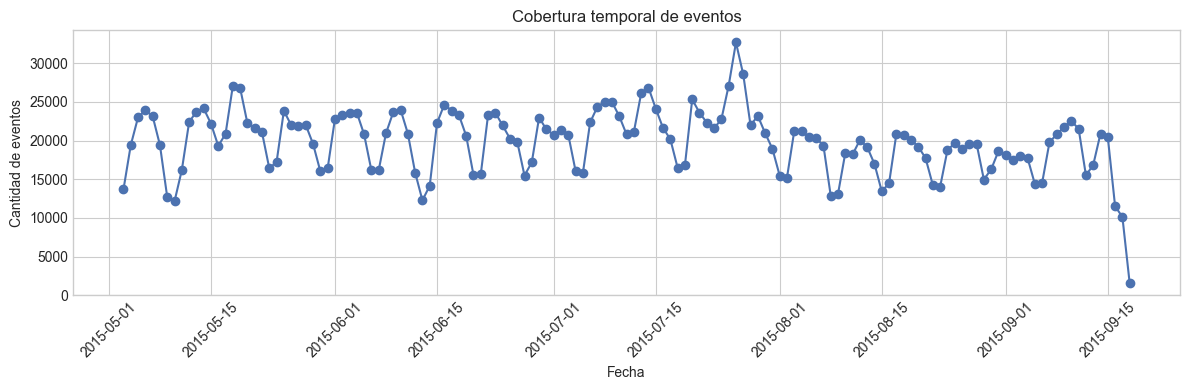

In [4]:
daily_events = (
    events.assign(date=events["event_time"].dt.date.astype("string"))
    .groupby("date")
    .size()
    .rename("event_count")
    .reset_index()
)

display(daily_events.head())

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(daily_events["date"]), daily_events["event_count"], marker="o")
plt.title("Cobertura temporal de eventos")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Reconstrucción de sesiones

RetailRocket no trae sesiones explícitas. Se reconstruyen sesiones por `visitorid` cortando cuando hay mas de 30 minutos de inactividad entre eventos consecutivos del mismo visitante.


In [5]:
def reconstruir_sesiones_retailrocket(events_df, inactivity_minutes=30):
    eventos = events_df.sort_values(["visitorid", "event_time"]).copy()
    eventos["prev_time"] = eventos.groupby("visitorid")["event_time"].shift(1)
    eventos["gap_minutes"] = (
        (eventos["event_time"] - eventos["prev_time"]).dt.total_seconds() / 60.0
    )
    eventos["new_session"] = eventos["prev_time"].isna() | (eventos["gap_minutes"] > inactivity_minutes)
    eventos["session_index"] = eventos.groupby("visitorid")["new_session"].cumsum().astype(int)
    eventos["session_id"] = eventos["visitorid"].astype(str) + "_" + eventos["session_index"].astype(str)
    return eventos.drop(columns=["prev_time"])


events_with_sessions = reconstruir_sesiones_retailrocket(events, inactivity_minutes=INACTIVITY_MINUTES)

session_event_counts = events_with_sessions.groupby("session_id").size().rename("event_count")
session_reconstruction_summary = pd.DataFrame(
    [
        {"metrica": "sesiones_reconstruidas", "valor": int(events_with_sessions["session_id"].nunique())},
        {"metrica": "eventos_por_sesion_media", "valor": float(session_event_counts.mean())},
        {"metrica": "eventos_por_sesion_mediana", "valor": float(session_event_counts.median())},
        {"metrica": "eventos_por_sesion_max", "valor": int(session_event_counts.max())},
    ]
)

display(session_reconstruction_summary)
display(events_with_sessions.head())


,metrica,valor
0,sesiones_reconstruidas,1.761675e+06
1,eventos_por_sesion_media,1.564478e+00
2,eventos_por_sesion_mediana,1.000000e+00
3,eventos_por_sesion_max,4.170000e+02


,timestamp,visitorid,event,itemid,transactionid,event_time,event_type,gap_minutes,new_session,session_index,session_id
0,1442004589439,0,view,285930,NaN,2015-09-11 20:49:49.439000+00:00,view,NaN,True,1,0_1
1,1442004759591,0,view,357564,NaN,2015-09-11 20:52:39.591000+00:00,view,2.835867,False,1,0_1
2,1442004917175,0,view,67045,NaN,2015-09-11 20:55:17.175000+00:00,view,2.626400,False,1,0_1
3,1439487966444,1,view,72028,NaN,2015-08-13 17:46:06.444000+00:00,view,NaN,True,1,1_1
4,1438969904567,2,view,325215,NaN,2015-08-07 17:51:44.567000+00:00,view,NaN,True,1,2_1


Distribución de tipos de evento:


,event_type,count
0,view,2664312
1,cart,69332
2,purchase,22457


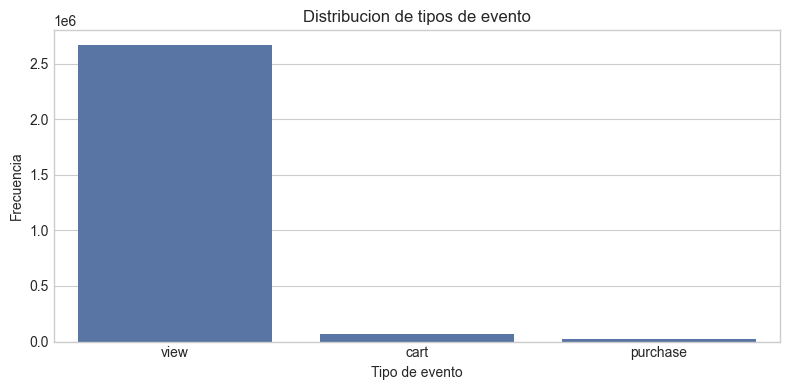

In [6]:
event_distribution = events_with_sessions["event_type"].value_counts().rename_axis("event_type").reset_index(name="count")
display(event_distribution)

plt.figure(figsize=(8, 4))
sns.barplot(data=event_distribution, x="event_type", y="count")
plt.title("Distribucion de tipos de evento")
plt.xlabel("Tipo de evento")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


#### Secuencias por sesion para next-item prediction

Se construyen secuencias de items por sesión. Igual que antes, se eliminan duplicados consecutivos del mismo producto.


In [7]:
def eliminar_duplicados_consecutivos(items):
    salida = []
    for item in items:
        if not salida or salida[-1] != item:
            salida.append(item)
    return salida


session_sequences = (
    events_with_sessions.groupby("session_id")
    .agg(
        visitorid=("visitorid", "last"),
        items=("itemid", lambda serie: eliminar_duplicados_consecutivos(serie.astype(int).tolist())),
        event_types=("event_type", list),
        start_time=("event_time", "min"),
        end_time=("event_time", "max"),
        raw_event_count=("itemid", "size"),
    )
    .reset_index()
)
session_sequences["session_len"] = session_sequences["items"].apply(len)
session_sequences = session_sequences[session_sequences["session_len"] >= MIN_SESSION_LEN].copy().reset_index(drop=True)

display(session_sequences.head())
print(f"Sesiones utiles para next-item prediction: {len(session_sequences):,}")


,session_id,visitorid,items,event_types,start_time,end_time,raw_event_count,session_len
0,0_1,0,"[285930, 357564, 67045]","[view, view, view]",2015-09-11 20:49:49.439000+00:00,2015-09-11 20:55:17.175000+00:00,3,3
1,1000001_2,1000001,"[202293, 424515, 230432]","[view, view, view]",2015-07-24 20:18:15.303000+00:00,2015-07-24 20:35:57.029000+00:00,3,3
2,1000003_1,1000003,"[228932, 150875]","[view, view]",2015-08-13 08:32:44.125000+00:00,2015-08-13 08:34:37.509000+00:00,2,2
3,1000018_1,1000018,"[278214, 19366, 256393]","[view, view, view]",2015-05-21 04:41:16.435000+00:00,2015-05-21 04:41:37.756000+00:00,3,3
4,1000028_1,1000028,"[131805, 427923, 419635, 91443, 170390]","[view, view, view, view, view]",2015-06-18 07:19:19.137000+00:00,2015-06-18 07:34:11.193000+00:00,5,5


Sesiones utiles para next-item prediction: 263,899


Longitud de sesiones:


,valor
count,263899.000000
mean,3.704182
std,5.041393
min,2.000000
50%,2.000000
75%,4.000000
90%,6.000000
95%,9.000000
max,415.000000


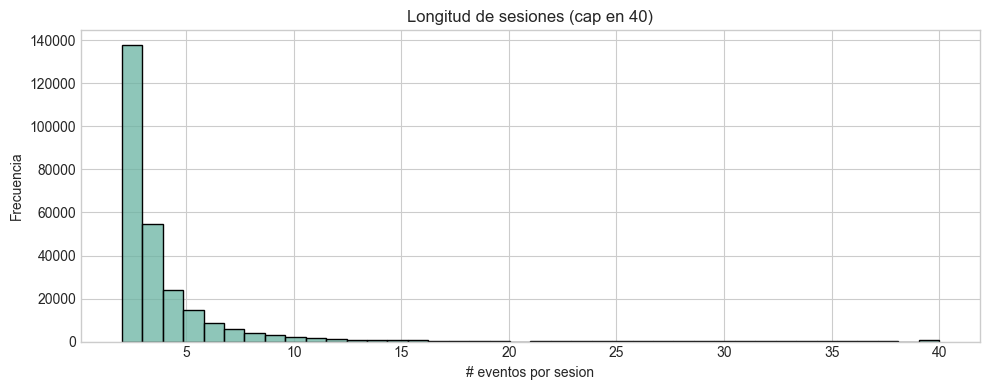

In [8]:
session_len_stats = session_sequences["session_len"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).to_frame(name="valor")
display(session_len_stats)

session_len_plot = session_sequences["session_len"].clip(upper=SESSION_LEN_CAP)

plt.figure(figsize=(10, 4))
sns.histplot(session_len_plot, bins=SESSION_LEN_CAP, color="#69b3a2")
plt.title(f"Longitud de sesiones (cap en {SESSION_LEN_CAP})")
plt.xlabel("# eventos por sesion")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Popularidad de productos:


,event_count
itemid,
187946,3412
461686,2978
5411,2334
370653,1854
219512,1800
257040,1647
298009,1642
96924,1633
309778,1628


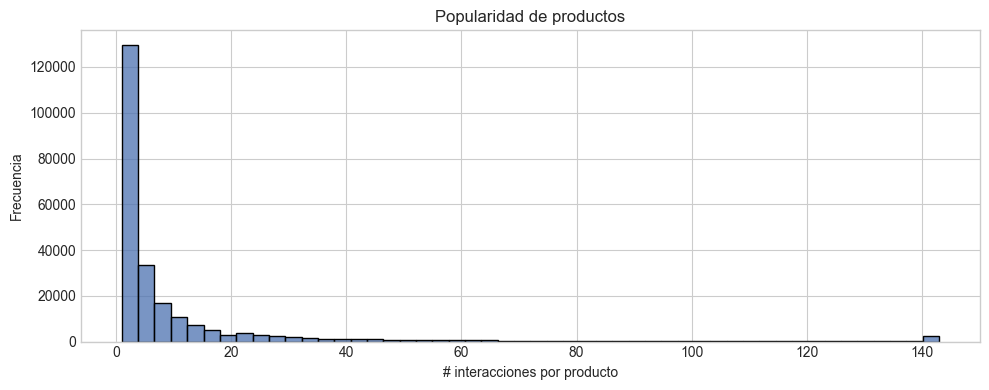

In [9]:
item_popularity = events_with_sessions["itemid"].value_counts()
display(item_popularity.head(10).rename("event_count").to_frame())

plt.figure(figsize=(10, 4))
sns.histplot(item_popularity.clip(upper=item_popularity.quantile(0.99)), bins=50)
plt.title("Popularidad de productos")
plt.xlabel("# interacciones por producto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Sparsity del problema:


In [10]:
n_sessions = session_sequences["session_id"].nunique()
n_items = events_with_sessions["itemid"].nunique()
n_interactions = int(session_sequences["session_len"].sum())
sparsity = 1 - (n_interactions / (n_sessions * n_items))

print(f"Sesiones unicas: {n_sessions:,}")
print(f"Items unicos: {n_items:,}")
print(f"Interacciones utiles en secuencias: {n_interactions:,}")
print(f"Sparsity: {sparsity:.6f}")


Sesiones unicas: 263,899
Items unicos: 235,061
Interacciones utiles en secuencias: 977,530
Sparsity: 0.999984


Actividad por hora del dia (UTC):


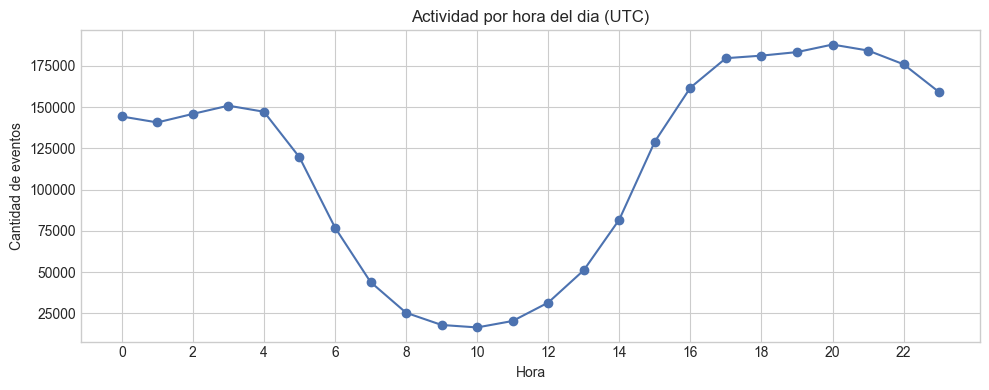

In [11]:
hourly_activity = (
    events_with_sessions.assign(hour=events_with_sessions["event_time"].dt.hour)
    .groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(10, 4))
plt.plot(hourly_activity.index, hourly_activity.values, marker="o")
plt.title("Actividad por hora del dia (UTC)")
plt.xlabel("Hora")
plt.ylabel("Cantidad de eventos")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


Transiciones de eventos:


,from_event,to_event,count
0,view,view,878014
3,view,cart,49710
2,cart,view,26256
6,cart,purchase,12136
4,cart,cart,11303
5,purchase,view,7382
7,purchase,purchase,4839
1,view,purchase,4544
8,purchase,cart,242


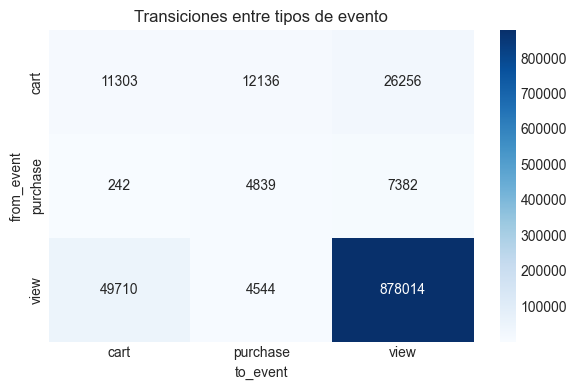

In [12]:
event_transition_counter = Counter()

for event_list in events_with_sessions.groupby("session_id")["event_type"].apply(list):
    for prev_event, next_event in zip(event_list[:-1], event_list[1:]):
        event_transition_counter[(prev_event, next_event)] += 1

transition_df = pd.DataFrame(
    [
        {"from_event": src, "to_event": dst, "count": count}
        for (src, dst), count in event_transition_counter.items()
    ]
)

display(transition_df.sort_values("count", ascending=False).head(15))

transition_matrix = transition_df.pivot_table(index="from_event", columns="to_event", values="count", fill_value=0)
plt.figure(figsize=(6, 4))
sns.heatmap(transition_matrix, annot=True, fmt=".0f", cmap="Blues")
plt.title("Transiciones entre tipos de evento")
plt.tight_layout()
plt.show()


#### Exploracion inicial de metadatos de producto

RetailRocket no trae columnas del estilo `brand`, `category_code` o `price`. Las propiedades vienen en formato **key-value**. Se exploran por chunks para identificar que tan interesantes son para etapas posteriores como reranking o híbridos con metadatos.


In [13]:
def explorar_item_properties(file_paths, chunksize=1_000_000):
    property_counter = Counter()
    total_rows = 0
    category_rows = 0
    sample_rows = []

    for file_path in file_paths:
        for chunk in pd.read_csv(file_path, chunksize=chunksize):
            total_rows += len(chunk)
            property_counter.update(chunk["property"].astype(str).tolist())
            category_mask = chunk["property"].astype(str).eq("categoryid")
            category_rows += int(category_mask.sum())
            if len(sample_rows) < 10:
                sample_rows.extend(chunk.head(5).to_dict(orient="records"))

    top_properties = pd.DataFrame(property_counter.most_common(20), columns=["property", "count"])
    sample_df = pd.DataFrame(sample_rows[:10])
    return total_rows, category_rows, top_properties, sample_df


property_paths = [os.path.join(DATA_PATH, file_name) for file_name in ITEM_PROPERTIES_FILES]
total_property_rows, category_property_rows, top_properties_df, property_sample_df = explorar_item_properties(
    property_paths,
    chunksize=PROPERTY_CHUNKSIZE,
)

properties_summary = pd.DataFrame(
    [
        {"metrica": "property_rows_total", "valor": int(total_property_rows)},
        {"metrica": "categoryid_rows", "valor": int(category_property_rows)},
        {"metrica": "categoryid_share", "valor": round(category_property_rows / total_property_rows, 4)},
    ]
)

display(properties_summary)
display(top_properties_df)
display(property_sample_df)


,metrica,valor
0,property_rows_total,2.027590e+07
1,categoryid_rows,7.882140e+05
2,categoryid_share,3.890000e-02


,property,count
0,888,3000398
1,790,1790516
2,available,1503639
3,categoryid,788214
4,6,631471
5,283,597419
6,776,574220
7,678,481966
8,364,476486
9,202,448938


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513
5,1437879600000,426662,839,641987 367680
6,1437879600000,51795,776,884498
7,1432436400000,345988,678,127431
8,1439694000000,190600,987,727751 n2280.000 377738
9,1434250800000,223911,689,150169 610517


#### Jerarquía de categorías

RetailRocket incluye una jerarquía simple de categorías en `category_tree.csv`.

In [14]:
category_tree = pd.read_csv(os.path.join(DATA_PATH, CATEGORY_TREE_FILE))
category_tree["parentid"] = pd.to_numeric(category_tree["parentid"], errors="coerce")

category_tree_summary = pd.DataFrame(
    [
        {"metrica": "category_nodes", "valor": int(category_tree["categoryid"].nunique())},
        {"metrica": "root_categories", "valor": int(category_tree["parentid"].isna().sum())},
        {"metrica": "non_root_categories", "valor": int(category_tree["parentid"].notna().sum())},
    ]
)

display(category_tree_summary)
display(category_tree.head(10))


,metrica,valor
0,category_nodes,1669
1,root_categories,25
2,non_root_categories,1644


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0
7,1146,542.0
8,1140,542.0
9,1479,1537.0


#### Conclusiones del análisis exploratorio

RetailRocket si permite formular un problema de recomendación secuencial en sesiones, pero en este caso las sesiones deben reconstruirse a partir de `visitorid` y brechas de inactividad. Si bien se reconstruyen cerca de 1.76 millones de sesiones, la mayoria son extremadamente cortas y, tras exigir longitud minima 2 para next-item prediction, quedan solo 263899 secuencias utiles con mediana **2 eventos** y media **3.70**. Esto quiere decir que la señal disponible vuelve a estar muy concentrada en interacciones recientes y transiciones locales.

La distribucion de eventos muestra que nuevamente predominan los `view`, mientras que `cart` y `purchase` son menos frecuentes. Esto también aparece en la matriz de transiciones, donde `view -> view` domina por gran margen.

La estructura del problema tambien sugiere que **popularidad, co-ocurrencias locales e informacion de recencia** deberian ser señales competitivas. La sparsity es extrema (`0.999984`), hay una cola larga marcada en popularidad de items y la mayoria de las sesiones observables son cortas.

Respecto a metadatos, RetailRocket ofrece más estructura auxiliar que un simple log de eventos, pero en un formato más dificil de usar, ya que las propiedades vienen en esquema **key-value**, muchas aparecen como códigos numéricos y `categoryid` solo es una de varias propiedades posibles.


### 2. Split temporal y preparacion para baselines

Ahora se replica la lógica del pipeline principal, split temporal estricto por `end_time`, filtrado iterativo usando solo soporte de train y construcción de casos `prefix -> target` para evaluar recomendación next-item.


In [15]:
def filtrar_pares_por_catalogo(items, event_types, catalogo):
    items_filtrados = []
    eventos_filtrados = []

    for item, event_type in zip(items, event_types):
        if item in catalogo:
            items_filtrados.append(item)
            eventos_filtrados.append(event_type)

    return items_filtrados, eventos_filtrados


def aplicar_filtrado_split(split_df, catalogo, min_session_len):
    split_filtrado = split_df.copy()
    if split_filtrado.empty:
        split_filtrado["session_len"] = pd.Series(dtype="int64")
        return split_filtrado.reset_index(drop=True)

    pares_filtrados = [
        filtrar_pares_por_catalogo(fila.items, fila.event_types, catalogo)
        for fila in split_filtrado.itertuples(index=False)
    ]
    split_filtrado["items"] = [par[0] for par in pares_filtrados]
    split_filtrado["event_types"] = [par[1] for par in pares_filtrados]
    split_filtrado["session_len"] = split_filtrado["items"].apply(len)
    split_filtrado = split_filtrado[split_filtrado["session_len"] >= min_session_len].copy()
    return split_filtrado.reset_index(drop=True)


def separar_sesiones_por_ventanas_retailrocket(session_df, validation_days=7, test_days=7, drop_last_day=True):
    sesiones_ordenadas = session_df.sort_values("end_time").reset_index(drop=True)
    fechas_fin = sesiones_ordenadas["end_time"].dt.normalize()
    fechas_unicas = fechas_fin.drop_duplicates().sort_values().reset_index(drop=True)

    if drop_last_day and len(fechas_unicas) >= validation_days + test_days + 2:
        fecha_max = fechas_unicas.iloc[-1]
        sesiones_ordenadas = sesiones_ordenadas[fechas_fin < fecha_max].copy().reset_index(drop=True)
        fechas_fin = sesiones_ordenadas["end_time"].dt.normalize()
        fechas_unicas = fechas_fin.drop_duplicates().sort_values().reset_index(drop=True)

    dias_necesarios = validation_days + test_days + 1
    if len(fechas_unicas) < dias_necesarios:
        raise ValueError("No hay suficientes fechas distintas para crear train, validation y test.")

    inicio_test = fechas_unicas.iloc[-test_days]
    inicio_validacion = fechas_unicas.iloc[-(test_days + validation_days)]

    train_df = sesiones_ordenadas[fechas_fin < inicio_validacion].copy()
    val_df = sesiones_ordenadas[(fechas_fin >= inicio_validacion) & (fechas_fin < inicio_test)].copy()
    test_df = sesiones_ordenadas[fechas_fin >= inicio_test].copy()
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def filtrar_items_train_y_proyectar_splits_retailrocket(train_df, val_df, test_df, min_session_len=2, min_item_support=5):
    train_filtrado = train_df.copy()

    while True:
        sesiones_antes = len(train_filtrado)
        eventos_antes = int(train_filtrado["session_len"].sum())

        soporte_items = Counter(item for secuencia in train_filtrado["items"] for item in secuencia)
        catalogo_soportado = {item for item, soporte in soporte_items.items() if soporte >= min_item_support}

        train_filtrado = aplicar_filtrado_split(train_filtrado, catalogo_soportado, min_session_len)

        sesiones_despues = len(train_filtrado)
        eventos_despues = int(train_filtrado["session_len"].sum())
        if (sesiones_antes, eventos_antes) == (sesiones_despues, eventos_despues):
            break

    catalogo_train = {item for secuencia in train_filtrado["items"] for item in secuencia}
    val_filtrado = aplicar_filtrado_split(val_df, catalogo_train, min_session_len)
    test_filtrado = aplicar_filtrado_split(test_df, catalogo_train, min_session_len)
    return train_filtrado.reset_index(drop=True), val_filtrado, test_filtrado, catalogo_train


def construir_resumen_splits(name, df):
    return {
        "split": name,
        "sesiones": len(df),
        "interacciones": int(df["session_len"].sum()) if not df.empty else 0,
        "items_unicos": len({item for secuencia in df["items"] for item in secuencia}) if not df.empty else 0,
        "inicio": df["end_time"].min() if not df.empty else pd.NaT,
        "fin": df["end_time"].max() if not df.empty else pd.NaT,
    }


def build_eval_cases(session_df, max_session_len=20):
    eval_cases = session_df.copy()
    eval_cases["prefix_items"] = eval_cases["items"].apply(lambda seq: seq[:-1][-max_session_len:])
    eval_cases["prefix_event_types"] = eval_cases["event_types"].apply(lambda seq: seq[:-1][-max_session_len:])
    eval_cases["target_item"] = eval_cases["items"].apply(lambda seq: seq[-1])
    eval_cases["target_event_type"] = eval_cases["event_types"].apply(lambda seq: seq[-1])
    eval_cases["prefix_len"] = eval_cases["prefix_items"].apply(len)
    eval_cases = eval_cases[eval_cases["prefix_len"] >= 1].copy().reset_index(drop=True)
    return eval_cases


In [16]:
session_sequences_for_split = session_sequences.copy()

train_sessions_raw, val_sessions_raw, test_sessions_raw = separar_sesiones_por_ventanas_retailrocket(
    session_sequences_for_split,
    validation_days=VALIDATION_DAYS,
    test_days=TEST_DAYS,
    drop_last_day=DROP_LAST_DAY_FROM_SPLIT,
)

train_sessions, val_sessions, test_sessions, train_catalog = filtrar_items_train_y_proyectar_splits_retailrocket(
    train_sessions_raw,
    val_sessions_raw,
    test_sessions_raw,
    min_session_len=MIN_SESSION_LEN,
    min_item_support=MIN_ITEM_SUPPORT,
)

split_summary = pd.DataFrame([
    construir_resumen_splits("train", train_sessions),
    construir_resumen_splits("validation", val_sessions),
    construir_resumen_splits("test", test_sessions),
])

print(f"Drop ultimo dia para split: {DROP_LAST_DAY_FROM_SPLIT}")
print(f"Ventanas: validation={VALIDATION_DAYS} dias, test={TEST_DAYS} dias")
print(f"Catalogo final de train: {len(train_catalog):,} items")
display(split_summary)


Drop ultimo dia para split: True
Ventanas: validation=7 dias, test=7 dias
Catalogo final de train: 34,542 items


,split,sesiones,interacciones,items_unicos,inicio,fin
0,train,187639,713906,34542,2015-05-03 03:03:11.370000+00:00,2015-09-03 23:59:35.612000+00:00
1,validation,8511,29313,10772,2015-09-04 00:03:19.123000+00:00,2015-09-10 23:59:46.757000+00:00
2,test,7407,26000,9717,2015-09-11 00:00:31.036000+00:00,2015-09-17 23:57:34.997000+00:00


In [17]:
train_eval = build_eval_cases(train_sessions, max_session_len=MAX_SESSION_LEN)
val_eval = build_eval_cases(val_sessions, max_session_len=MAX_SESSION_LEN)
test_eval = build_eval_cases(test_sessions, max_session_len=MAX_SESSION_LEN)

train_item_popularity = Counter(item for seq in train_sessions["items"] for item in seq)
popular_items = [item for item, _ in train_item_popularity.most_common()]

print(f"Casos de train: {len(train_eval):,}")
print(f"Casos de validation: {len(val_eval):,}")
print(f"Casos de test: {len(test_eval):,}")
display(test_eval[["session_id", "prefix_items", "target_item", "prefix_len", "end_time"]].head())


Casos de train: 187,639
Casos de validation: 8,511
Casos de test: 7,407


,session_id,prefix_items,target_item,prefix_len,end_time
0,792422_2,"[158220, 245085, 224231]",21249,3,2015-09-11 00:00:31.036000+00:00
1,635436_1,[22493],168411,1,2015-09-11 00:00:53.249000+00:00
2,1288705_5,[19326],25375,1,2015-09-11 00:01:30.604000+00:00
3,100799_2,"[224231, 120164, 99187, 366666]",106358,4,2015-09-11 00:02:24.338000+00:00
4,1168090_1,"[85674, 155871, 233405]",155871,3,2015-09-11 00:07:17.320000+00:00


### 3. Baselines iniciales

Con el split temporal ya listo, se parte con  `random`, `most_popular` e `item_knn`.


In [18]:
from ECommerce_Models import EntrenarGru4Rec, EntrenarSasRec
from ECommerce_Experiments import ConstruirItemKnnRecomendador, ConstruirSequentialRulesRecomendador, ConstruirRecomendadorHibrido, ConstruirRecomendadorPopularidadReciente

RANDOM_STATE = 42
TOP_KS = (5, 10, 20)
rng = np.random.default_rng(42)


def recall_at_k(recommended, relevant, k):
    recommended_k = recommended[:k]
    return len(set(recommended_k) & set(relevant)) / max(len(relevant), 1)


def dcg_at_k(recommended, relevant, k):
    dcg = 0.0
    relevant_set = set(relevant)
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant_set:
            dcg += 1 / np.log2(rank + 1)
    return dcg


def ndcg_at_k(recommended, relevant, k):
    ideal = dcg_at_k(relevant[:k], relevant, k)
    if ideal == 0:
        return 0.0
    return dcg_at_k(recommended, relevant, k) / ideal


def average_precision_at_k(recommended, relevant, k):
    relevant_set = set(relevant)
    hits = 0
    precision_sum = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant_set:
            hits += 1
            precision_sum += hits / rank
    return precision_sum / max(len(relevant_set), 1)


def evaluate_recommender(recommender_fn, eval_cases, ks=(5, 10, 20), label="model"):
    rows = []
    for k in ks:
        recall_scores = []
        ndcg_scores = []
        map_scores = []

        for fila in eval_cases.itertuples(index=False):
            recs = recommender_fn(fila.prefix_items, k=k)
            relevant = [fila.target_item]
            recall_scores.append(recall_at_k(recs, relevant, k))
            ndcg_scores.append(ndcg_at_k(recs, relevant, k))
            map_scores.append(average_precision_at_k(recs, relevant, k))

        rows.append({
            "modelo": label,
            "k": k,
            "recall": float(np.mean(recall_scores)),
            "ndcg": float(np.mean(ndcg_scores)),
            "map": float(np.mean(map_scores)),
        })

    return pd.DataFrame(rows)


def plot_metric_comparison(results_df, figsize=(15, 8)):
    plot_df = results_df[results_df["k"] == 20].copy()
    metrics = ["recall", "ndcg", "map"]
    splits = ["validation", "test"]

    fig, axes = plt.subplots(len(splits), len(metrics), figsize=figsize)

    for row_idx, split in enumerate(splits):
        split_df = plot_df[plot_df["split"] == split].copy()
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            sns.barplot(data=split_df, x="modelo", y=metric, hue="modelo", palette="deep", legend=False, ax=ax)
            ax.set_title(f"{metric.upper()}@20 en {split}")
            ax.set_xlabel("Modelo")
            ax.set_ylabel(f"{metric.upper()}@20")
            ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def recommend_random(prefix_items, k=10):
    vistos = set(prefix_items)
    candidatos = [item for item in popular_items if item not in vistos]
    if len(candidatos) <= k:
        return candidatos[:k]
    return rng.choice(candidatos, size=k, replace=False).tolist()


def recommend_most_popular(prefix_items, k=10):
    vistos = set(prefix_items)
    return [item for item in popular_items if item not in vistos][:k]


item_knn_recommender = ConstruirItemKnnRecomendador(
    train_sessions,
    max_neighbors=100,
    window_size=3,
    last_n=5,
)


Validation


,modelo,k,recall,ndcg,map
6,item_knn,5,0.252262,0.178727,0.154424
3,most_popular,5,0.003760,0.001654,0.000987
0,random,5,0.000000,0.000000,0.000000
7,item_knn,10,0.322641,0.201522,0.163850
4,most_popular,10,0.008460,0.003116,0.001558
1,random,10,0.000117,0.000117,0.000117
8,item_knn,20,0.387264,0.217955,0.168408
5,most_popular,20,0.014099,0.004526,0.001937
2,random,20,0.000117,0.000032,0.000010


Test


,modelo,k,recall,ndcg,map
6,item_knn,5,0.238558,0.168000,0.144719
3,most_popular,5,0.004185,0.002095,0.001418
0,random,5,0.000135,0.000085,0.000068
7,item_knn,10,0.316187,0.193190,0.155164
4,most_popular,10,0.009045,0.003636,0.002036
1,random,10,0.000270,0.000095,0.000044
8,item_knn,20,0.384906,0.210559,0.159927
5,most_popular,20,0.013906,0.004855,0.002366
2,random,20,0.000135,0.000035,0.000010


,modelo,k,recall,ndcg,map,split
15,item_knn,5,0.238558,0.168000,0.144719,test
12,most_popular,5,0.004185,0.002095,0.001418,test
9,random,5,0.000135,0.000085,0.000068,test
16,item_knn,10,0.316187,0.193190,0.155164,test
13,most_popular,10,0.009045,0.003636,0.002036,test
10,random,10,0.000270,0.000095,0.000044,test
17,item_knn,20,0.384906,0.210559,0.159927,test
14,most_popular,20,0.013906,0.004855,0.002366,test
11,random,20,0.000135,0.000035,0.000010,test
6,item_knn,5,0.252262,0.178727,0.154424,validation


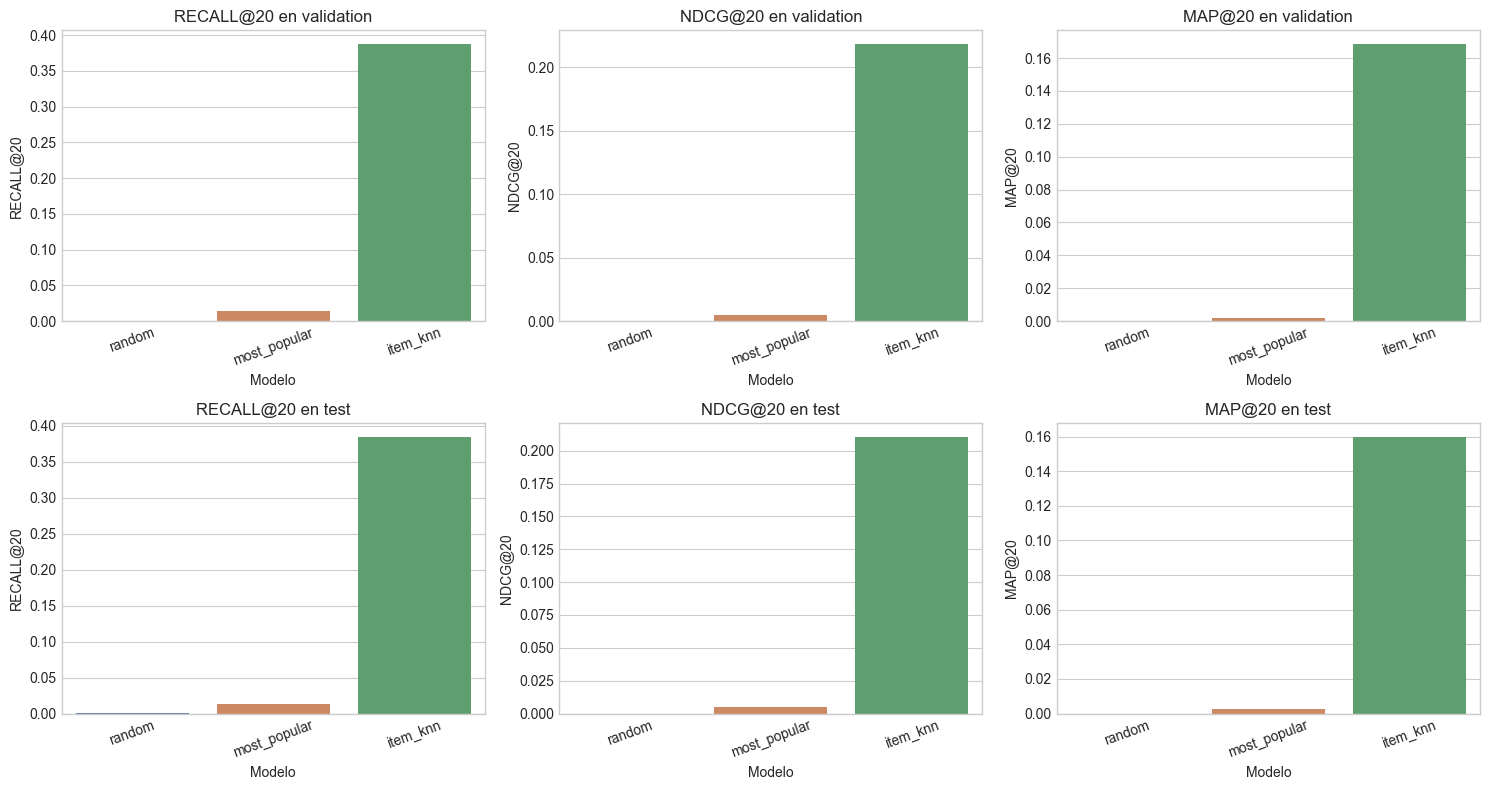

In [19]:
baseline_results_val = pd.concat([
    evaluate_recommender(recommend_random, val_eval, ks=TOP_KS, label="random"),
    evaluate_recommender(recommend_most_popular, val_eval, ks=TOP_KS, label="most_popular"),
    evaluate_recommender(item_knn_recommender.Recomendar, val_eval, ks=TOP_KS, label="item_knn"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_recommender(recommend_random, test_eval, ks=TOP_KS, label="random"),
    evaluate_recommender(recommend_most_popular, test_eval, ks=TOP_KS, label="most_popular"),
    evaluate_recommender(item_knn_recommender.Recomendar, test_eval, ks=TOP_KS, label="item_knn"),
], ignore_index=True)

baseline_comparison = pd.concat([
    baseline_results_val.assign(split="validation"),
    baseline_results_test.assign(split="test"),
], ignore_index=True)

print("Validation")
display(baseline_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(baseline_results_test.sort_values(["k", "recall"], ascending=[True, False]))

display(baseline_comparison.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(baseline_comparison, figsize=(15, 8))


### 4. Modelos neuronales secuenciales

Se replica el bloque neuronal del pipeline original con `GRU4Rec` y `SASRec`, usando los mismos casos `prefix -> target` y una configuracion liviana para comparar contra los baselines bajo el mismo split temporal.


In [20]:
gru4rec_recommender, gru4rec_history = EntrenarGru4Rec(
    train_sessions,
    max_session_len=MAX_SESSION_LEN,
    embedding_dim=64,
    hidden_dim=96,
    dropout=0.2,
    epochs=2,
    batch_size=512,
    learning_rate=1e-3,
    max_train_examples=120_000,
    usar_todos_los_prefijos=True,
    seed=RANDOM_STATE,
    device="cpu",
    verbose=True,
)

sasrec_recommender, sasrec_history = EntrenarSasRec(
    train_sessions,
    max_session_len=MAX_SESSION_LEN,
    embedding_dim=64,
    num_heads=2,
    num_layers=1,
    dropout=0.2,
    epochs=2,
    batch_size=256,
    learning_rate=1e-3,
    max_train_examples=80_000,
    usar_todos_los_prefijos=True,
    seed=RANDOM_STATE,
    device="cpu",
    verbose=True,
)

display(pd.DataFrame(gru4rec_history))
display(pd.DataFrame(sasrec_history))


Epoch 1/2 - loss: 10.2424
Epoch 2/2 - loss: 9.7282
Epoch 1/2 - loss: 10.3225
Epoch 2/2 - loss: 9.6733


,epoch,loss
0,1,10.242431
1,2,9.728167


,epoch,loss
0,1,10.322485
1,2,9.673275


Validation


,modelo,k,recall,ndcg,map
6,item_knn,5,0.252262,0.178727,0.154424
9,gru4rec,5,0.015979,0.010954,0.009306
12,sasrec,5,0.013512,0.009967,0.008810
3,most_popular,5,0.003760,0.001654,0.000987
0,random,5,0.000000,0.000000,0.000000
7,item_knn,10,0.322641,0.201522,0.163850
10,gru4rec,10,0.019504,0.012090,0.009772
13,sasrec,10,0.018329,0.011497,0.009426
4,most_popular,10,0.008460,0.003116,0.001558
1,random,10,0.000117,0.000117,0.000117


Test


,modelo,k,recall,ndcg,map
6,item_knn,5,0.238558,0.168000,0.144719
9,gru4rec,5,0.013771,0.010038,0.008816
12,sasrec,5,0.011071,0.008063,0.007068
3,most_popular,5,0.004185,0.002095,0.001418
0,random,5,0.000135,0.000085,0.000068
7,item_knn,10,0.316187,0.193190,0.155164
10,gru4rec,10,0.018496,0.011536,0.009418
13,sasrec,10,0.016471,0.009768,0.007747
4,most_popular,10,0.009045,0.003636,0.002036
1,random,10,0.000270,0.000095,0.000044


,modelo,k,recall,ndcg,map,split
21,item_knn,5,0.238558,0.168000,0.144719,test
24,gru4rec,5,0.013771,0.010038,0.008816,test
27,sasrec,5,0.011071,0.008063,0.007068,test
18,most_popular,5,0.004185,0.002095,0.001418,test
15,random,5,0.000135,0.000085,0.000068,test
22,item_knn,10,0.316187,0.193190,0.155164,test
25,gru4rec,10,0.018496,0.011536,0.009418,test
28,sasrec,10,0.016471,0.009768,0.007747,test
19,most_popular,10,0.009045,0.003636,0.002036,test
16,random,10,0.000270,0.000095,0.000044,test


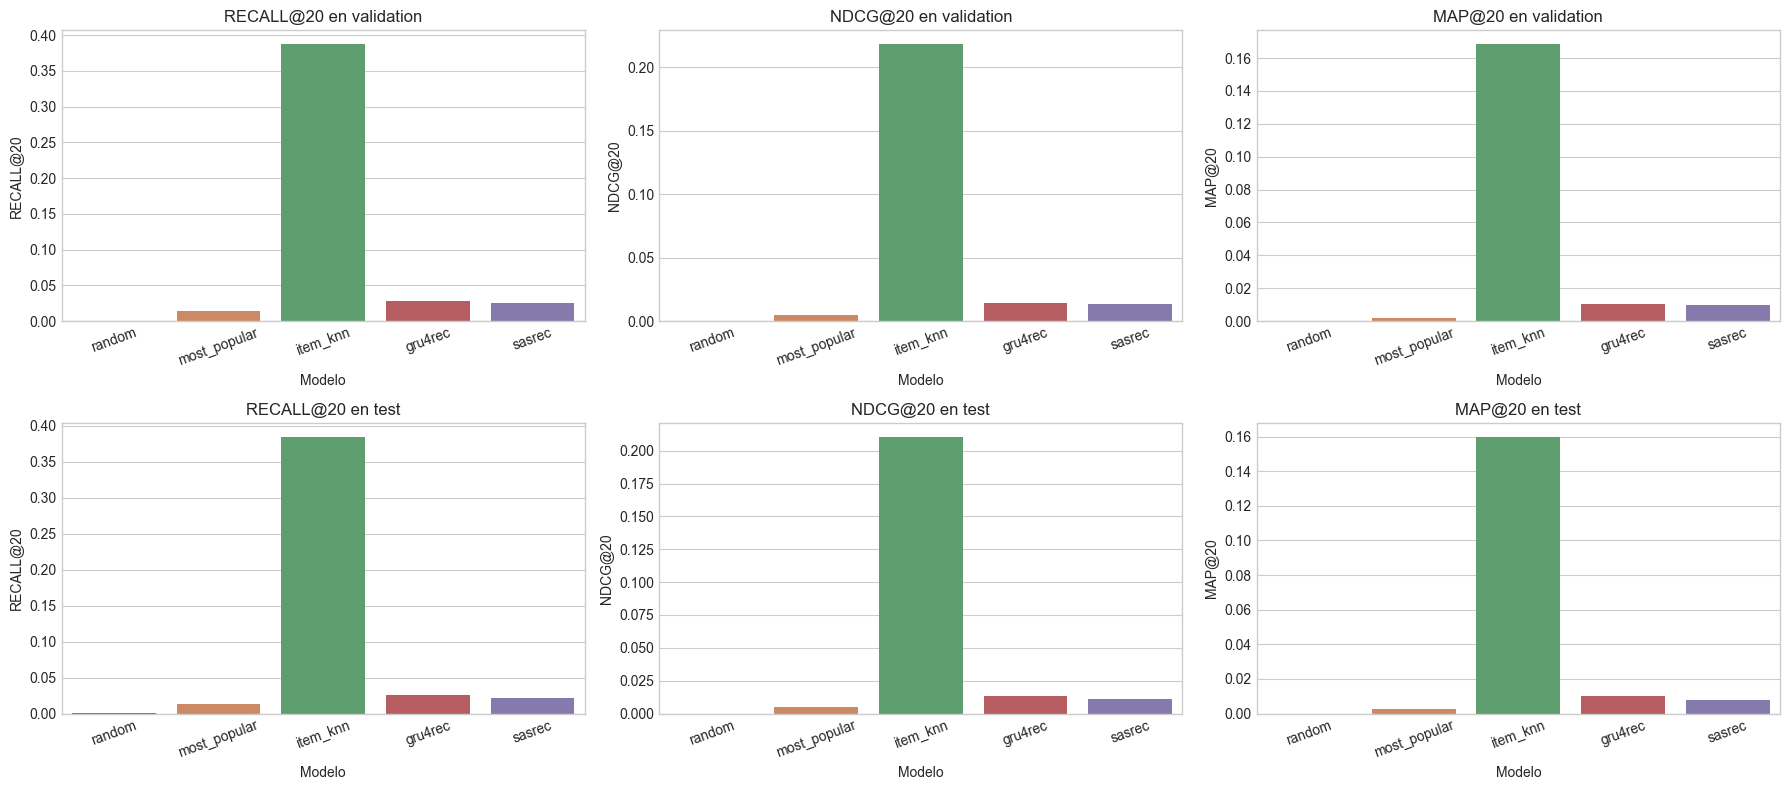

In [21]:
neural_results_val = pd.concat([
    evaluate_recommender(gru4rec_recommender.Recomendar, val_eval, ks=TOP_KS, label="gru4rec"),
    evaluate_recommender(sasrec_recommender.Recomendar, val_eval, ks=TOP_KS, label="sasrec"),
], ignore_index=True)

neural_results_test = pd.concat([
    evaluate_recommender(gru4rec_recommender.Recomendar, test_eval, ks=TOP_KS, label="gru4rec"),
    evaluate_recommender(sasrec_recommender.Recomendar, test_eval, ks=TOP_KS, label="sasrec"),
], ignore_index=True)

all_results_val = pd.concat([baseline_results_val, neural_results_val], ignore_index=True)
all_results_test = pd.concat([baseline_results_test, neural_results_test], ignore_index=True)
all_results = pd.concat([
    all_results_val.assign(split="validation"),
    all_results_test.assign(split="test"),
], ignore_index=True)

print("Validation")
display(all_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(all_results_test.sort_values(["k", "recall"], ascending=[True, False]))

display(all_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(all_results, figsize=(18, 8))


### 5. Reglas secuenciales e hibridos

Se agrega un bloque con reglas secuenciales puras y dos híbridos: `item_knn + gru4rec` e `item_knn + seq_rules`.


In [22]:
seq_rules_recommender = ConstruirSequentialRulesRecomendador(
    train_sessions,
    max_steps=10,
    max_rules_per_item=200,
    last_n=5,
)

hybrid_knn_gru_recommender = ConstruirRecomendadorHibrido(
    [("item_knn", item_knn_recommender, 0.75), ("gru4rec", gru4rec_recommender, 0.25)],
    popular_items=item_knn_recommender.popular_items,
)

hybrid_knn_rules_recommender = ConstruirRecomendadorHibrido(
    [("item_knn", item_knn_recommender, 0.60), ("seq_rules", seq_rules_recommender, 0.40)],
    popular_items=item_knn_recommender.popular_items,
)


In [23]:
experiment_results_val = pd.concat([
    evaluate_recommender(item_knn_recommender.Recomendar, val_eval, ks=TOP_KS, label="item_knn_mod"),
    evaluate_recommender(seq_rules_recommender.Recomendar, val_eval, ks=TOP_KS, label="seq_rules"),
    evaluate_recommender(hybrid_knn_gru_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_gru"),
    evaluate_recommender(hybrid_knn_rules_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_rules"),
], ignore_index=True)

experiment_results_test = pd.concat([
    evaluate_recommender(item_knn_recommender.Recomendar, test_eval, ks=TOP_KS, label="item_knn_mod"),
    evaluate_recommender(seq_rules_recommender.Recomendar, test_eval, ks=TOP_KS, label="seq_rules"),
    evaluate_recommender(hybrid_knn_gru_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_gru"),
    evaluate_recommender(hybrid_knn_rules_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_rules"),
], ignore_index=True)

print("Validation")
display(experiment_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(experiment_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
9,hybrid_knn_rules,5,0.263776,0.190026,0.165668
0,item_knn_mod,5,0.252262,0.178727,0.154424
3,seq_rules,5,0.247444,0.178719,0.155984
6,hybrid_knn_gru,5,0.244507,0.175086,0.152140
10,hybrid_knn_rules,10,0.336271,0.213502,0.175375
1,item_knn_mod,10,0.322641,0.201522,0.163850
4,seq_rules,10,0.310657,0.199338,0.164598
7,hybrid_knn_gru,10,0.310657,0.196512,0.161002
11,hybrid_knn_rules,20,0.399601,0.229574,0.179821
2,item_knn_mod,20,0.387264,0.217955,0.168408


Test


,modelo,k,recall,ndcg,map
9,hybrid_knn_rules,5,0.252329,0.179196,0.155011
3,seq_rules,5,0.240448,0.170350,0.147147
0,item_knn_mod,5,0.238558,0.168000,0.144719
6,hybrid_knn_gru,5,0.228298,0.163426,0.141972
10,hybrid_knn_rules,10,0.322803,0.202163,0.164593
1,item_knn_mod,10,0.316187,0.193190,0.155164
4,seq_rules,10,0.304577,0.191214,0.155831
7,hybrid_knn_gru,10,0.304307,0.188011,0.152125
11,hybrid_knn_rules,20,0.394087,0.220332,0.169658
2,item_knn_mod,20,0.384906,0.210559,0.159927


,modelo,k,recall,ndcg,map,split
51,hybrid_knn_rules,5,0.252329,0.179196,0.155011,test
45,seq_rules,5,0.240448,0.170350,0.147147,test
21,item_knn,5,0.238558,0.168000,0.144719,test
42,item_knn_mod,5,0.238558,0.168000,0.144719,test
48,hybrid_knn_gru,5,0.228298,0.163426,0.141972,test
24,gru4rec,5,0.013771,0.010038,0.008816,test
27,sasrec,5,0.011071,0.008063,0.007068,test
18,most_popular,5,0.004185,0.002095,0.001418,test
15,random,5,0.000135,0.000085,0.000068,test
52,hybrid_knn_rules,10,0.322803,0.202163,0.164593,test


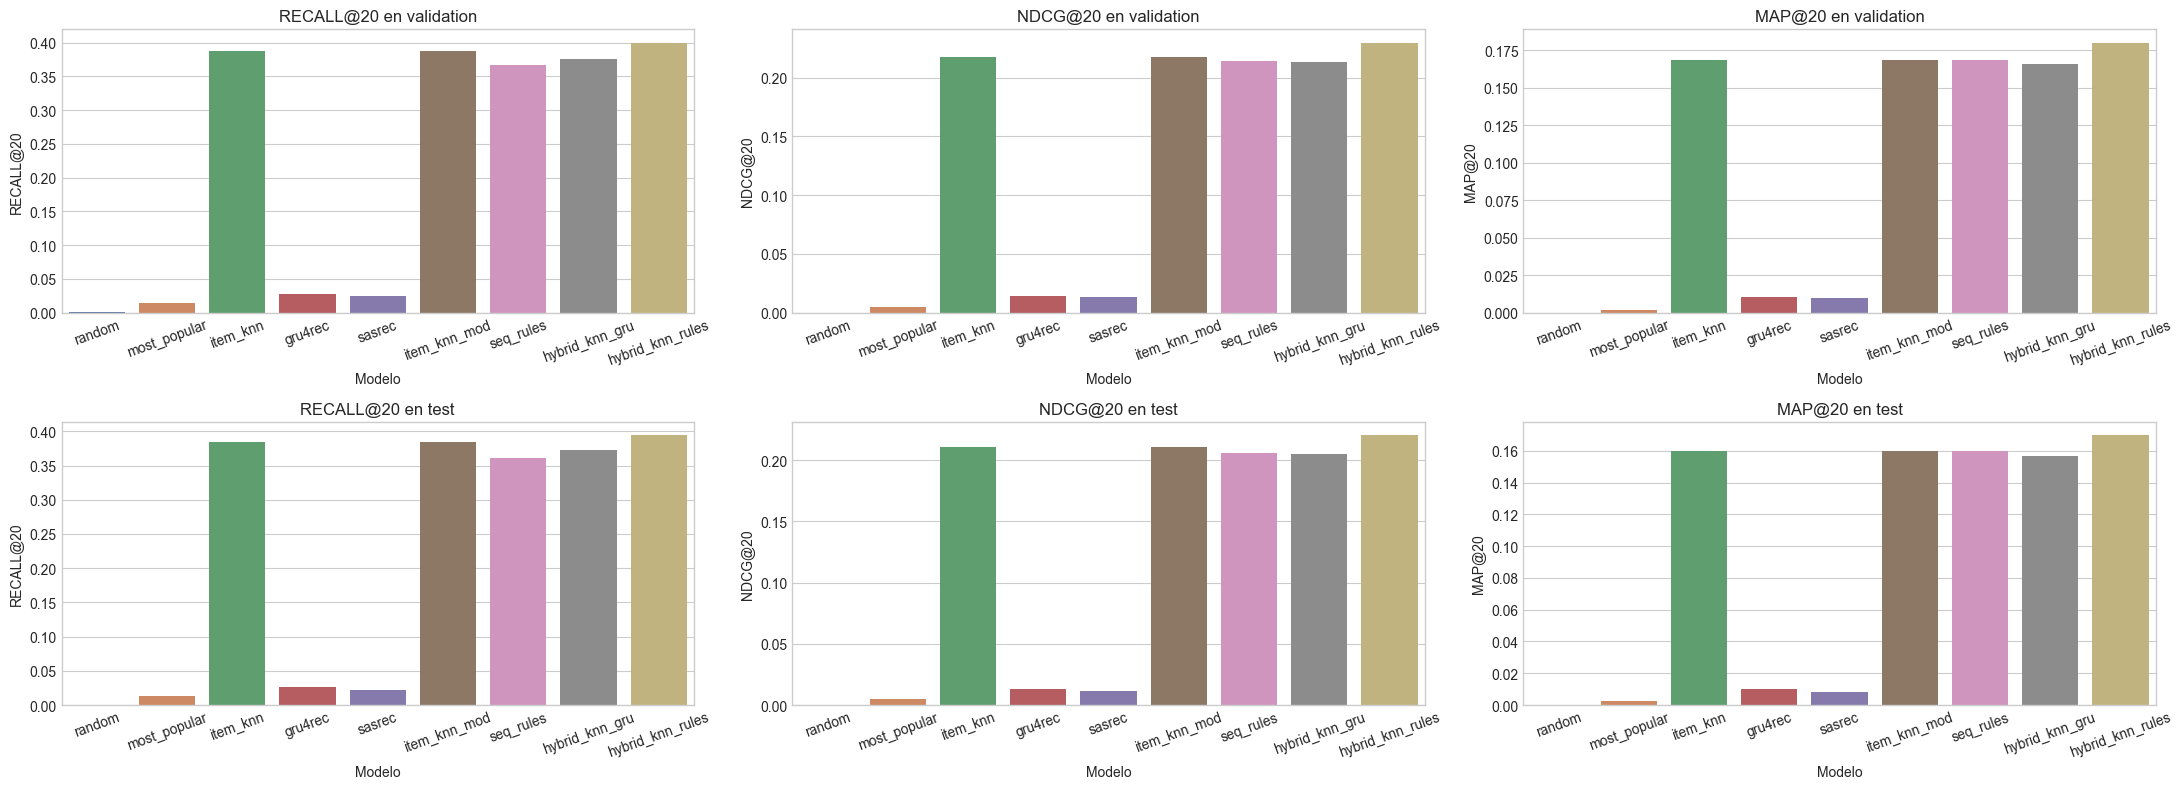

In [24]:
all_experiment_results = pd.concat([
    all_results_val.assign(split="validation"),
    all_results_test.assign(split="test"),
    experiment_results_val.assign(split="validation"),
    experiment_results_test.assign(split="test"),
], ignore_index=True)

display(all_experiment_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(all_experiment_results, figsize=(22, 8))


### 6. Metadatos mínimos por categoría

En RetailRocket la metadata no viene lista dentro del log de eventos. Para poder hacer una versión comparable con ECommerce.ipynb, se construye primero una versión mínima por item usando solo `categoryid`, calculada con informacion disponible hasta el final de `train`.


In [25]:
#Ultimo instante temporal observado en train. Se usa como corte para no incorporar metadata del futuro.
train_cutoff_time = train_sessions["end_time"].max()

#Catalogo final de items que sobrevivieron al filtrado de train.
train_catalog_items = set(train_catalog)


def construir_mapa_categoria_raiz(category_tree_df):
    #Convierte el árbol de categorias en un diccionario categoria -> categoria padre.
    parent_map = category_tree_df.set_index("categoryid")["parentid"].to_dict()
    
    #Cache para no recalcular muchas veces la misma categoria raiz.
    root_cache = {}

    def root_of(category_id):
        #Si la categoria viene nula, no hay raiz que calcular.
        if pd.isna(category_id):
            return np.nan
        category_id = int(category_id)

        #Si ya la calculamos antes, devolvemos el valor guardado.
        if category_id in root_cache:
            return root_cache[category_id]

        visited = set()
        current = category_id
        while True:
            #Si encontramos un ciclo, devolvemos la categoria original como respaldo.
            if current in visited:
                root_cache[category_id] = category_id
                return category_id
            visited.add(current)

            parent = parent_map.get(current)
            
            #Si no tiene padre, llegamos a la raiz.
            if pd.isna(parent):
                root_cache[category_id] = current
                return current
            
            #Seguimos subiendo en el arbol.
            current = int(parent)

    #Devuelve la funcion lista para usar sobre category_id.
    return root_of


def construir_metadata_items_categoria(file_paths, train_catalog_items, cutoff_time, category_tree_df, chunksize=1_000_000):
    #Aqui iremos guardando, para cada item, la categoría mas reciente disponible hasta el cutoff de train.
    latest_by_item = {}

    #Funcion auxiliar para obtener la categoria raiz.
    root_of = construir_mapa_categoria_raiz(category_tree_df)
    
    #Recorremos todos los archivos de propiedades.
    for file_path in file_paths:
        full_path = os.path.join(DATA_PATH, file_path)

        #Se lee por chunks para no cargar todo en memoria.
        reader = pd.read_csv(full_path, chunksize=chunksize)

        for chunk in reader:

            #Nos quedamos solo con la propiedad categoryid y los items que existen en el catalogo final de train
            chunk = chunk[(chunk["property"] == "categoryid") & (chunk["itemid"].isin(train_catalog_items))].copy()
            if chunk.empty:
                continue
            
            #Convertimos el timestamp original a datetime UTC.
            chunk["event_time"] = pd.to_datetime(chunk["timestamp"], unit="ms", utc=True, errors="coerce")
            
            #Eliminamos metadata posterior al fin de train para evitar leakage temporal.
            chunk = chunk[chunk["event_time"] <= cutoff_time].copy()
            if chunk.empty:
                continue
                
            #Convertimos el valor de la propiedad categoryid a numerico.
            chunk["categoryid"] = pd.to_numeric(chunk["value"], errors="coerce")
            
            #Quitamos filas invalidas.
            chunk = chunk.dropna(subset=["categoryid", "event_time"])
            if chunk.empty:
                continue
            
            #Ordenamos por item y tiempo para poder tomar la categoria mas reciente de cada item en este chunk.
            chunk = chunk.sort_values(["itemid", "event_time"])
            latest_chunk = chunk.groupby("itemid", as_index=False).tail(1)

            #Actualizamos el diccionario global item -> metadata reciente. Si ese item ya aparecio en otro chunk, conservamos la fila con timestamp mas nuevo.
            for row in latest_chunk.itertuples(index=False):
                prev = latest_by_item.get(int(row.itemid))
                if prev is None or row.event_time >= prev["event_time"]:
                    latest_by_item[int(row.itemid)] = {
                        "product_id": int(row.itemid),
                        "category_id": int(row.categoryid),
                        "event_time": row.event_time,
                    }
    
    #Convertimos el diccionario final a DataFrame.
    item_metadata = pd.DataFrame(latest_by_item.values())
    
    #Si no hubo metadata valida, devolvemos vacío.
    if item_metadata.empty:
        return item_metadata

    #Agregamos la categoria raiz para tener una señal más general.
    item_metadata["category_root"] = item_metadata["category_id"].apply(root_of)
    return item_metadata.sort_values("product_id").reset_index(drop=True)

#Construye la tabla final de metadata por item
item_metadata_rr = construir_metadata_items_categoria(
    ITEM_PROPERTIES_FILES,
    train_catalog_items=train_catalog_items,
    cutoff_time=train_cutoff_time,
    category_tree_df=category_tree,
    chunksize=PROPERTY_CHUNKSIZE,
)

metadata_summary_rr = pd.DataFrame([
    {"metrica": "train_catalog_items", "valor": len(train_catalog_items)},
    {"metrica": "items_con_categoryid", "valor": int(item_metadata_rr["product_id"].nunique()) if not item_metadata_rr.empty else 0},
    {"metrica": "cobertura_catalogo", "valor": float(item_metadata_rr["product_id"].nunique() / max(len(train_catalog_items), 1)) if not item_metadata_rr.empty else 0.0},
    {"metrica": "categorias_unicas", "valor": int(item_metadata_rr["category_id"].nunique()) if not item_metadata_rr.empty else 0},
    {"metrica": "roots_unicos", "valor": int(item_metadata_rr["category_root"].nunique()) if not item_metadata_rr.empty else 0},
    {"metrica": "cutoff_train", "valor": train_cutoff_time},
])

display(metadata_summary_rr)
display(item_metadata_rr.head())


,metrica,valor
0,train_catalog_items,34542
1,items_con_categoryid,33608
2,cobertura_catalogo,0.97296
3,categorias_unicas,799
4,roots_unicos,19
5,cutoff_train,2015-09-03 23:59:35.612000+00:00


,product_id,category_id,event_time,category_root
0,6,1091,2015-05-10 03:00:00+00:00,1600
1,15,722,2015-05-10 03:00:00+00:00,653
2,16,333,2015-06-28 03:00:00+00:00,1490
3,19,1171,2015-05-31 03:00:00+00:00,1532
4,25,72,2015-08-30 03:00:00+00:00,140


In [26]:
metadata_lookup_rr = item_metadata_rr.set_index("product_id").to_dict(orient="index") if not item_metadata_rr.empty else {}


def resumir_cobertura_metadata(eval_df, metadata_lookup):
    casos = eval_df.copy()
    casos["target_has_metadata"] = casos["target_item"].apply(lambda item: item in metadata_lookup)
    casos["last_prefix_has_metadata"] = casos["prefix_items"].apply(lambda seq: bool(seq) and seq[-1] in metadata_lookup)
    casos["both_have_metadata"] = casos.apply(lambda row: row["target_has_metadata"] and row["last_prefix_has_metadata"], axis=1)
    return pd.DataFrame([
        {"metrica": "casos", "valor": len(casos)},
        {"metrica": "target_con_metadata", "valor": float(casos["target_has_metadata"].mean()) if len(casos) else 0.0},
        {"metrica": "ultimo_prefijo_con_metadata", "valor": float(casos["last_prefix_has_metadata"].mean()) if len(casos) else 0.0},
        {"metrica": "ambos_con_metadata", "valor": float(casos["both_have_metadata"].mean()) if len(casos) else 0.0},
    ])


print("Validation")
display(resumir_cobertura_metadata(val_eval, metadata_lookup_rr))
print("Test")
display(resumir_cobertura_metadata(test_eval, metadata_lookup_rr))


Validation


,metrica,valor
0,casos,8511.000000
1,target_con_metadata,0.968041
2,ultimo_prefijo_con_metadata,0.968159
3,ambos_con_metadata,0.954529


Test


,metrica,valor
0,casos,7407.000000
1,target_con_metadata,0.967868
2,ultimo_prefijo_con_metadata,0.968948
3,ambos_con_metadata,0.953827


In [27]:
class RecomendadorPorScoresRR:
    def __init__(self, popular_items, generador_scores):
        self.popular_items = popular_items
        self.generador_scores = generador_scores

    def Puntuar(self, prefix_items, seen_items=None):
        vistos = set(prefix_items) if seen_items is None else set(seen_items)
        return self.generador_scores(prefix_items, vistos)

    def Recomendar(self, prefix_items, k=10, seen_items=None):
        vistos = set(prefix_items) if seen_items is None else set(seen_items)
        scores = self.Puntuar(prefix_items, seen_items=vistos)
        recomendaciones = [item for item, _ in sorted(scores.items(), key=lambda par: par[1], reverse=True)]
        if len(recomendaciones) < k:
            for item in self.popular_items:
                if item in vistos or item in recomendaciones:
                    continue
                recomendaciones.append(item)
                if len(recomendaciones) == k:
                    break
        return recomendaciones[:k]


def construir_recomendador_rerank_categoria(base_recommender, item_metadata_df, popular_items, candidate_k=100, weight_base=0.80, weight_category=0.15, weight_root=0.05):
    metadata_by_item = item_metadata_df.set_index("product_id").to_dict(orient="index")

    def generar_scores(prefix_items, seen_items):
        candidatos = base_recommender.Recomendar(prefix_items, k=candidate_k, seen_items=seen_items)
        if not candidatos:
            return {}

        ultimo_item = next((item for item in reversed(prefix_items) if item in metadata_by_item), None)
        ultimo_meta = metadata_by_item.get(ultimo_item)
        total_candidatos = len(candidatos)
        scores = {}

        for posicion, item in enumerate(candidatos, start=1):
            meta_item = metadata_by_item.get(item)
            score_base = 1 - ((posicion - 1) / max(total_candidatos - 1, 1))
            score_category = 0.0
            score_root = 0.0

            if ultimo_meta is not None and meta_item is not None:
                if meta_item["category_id"] == ultimo_meta["category_id"]:
                    score_category = 1.0
                if meta_item["category_root"] == ultimo_meta["category_root"]:
                    score_root = 1.0

            scores[item] = (weight_base * score_base + weight_category * score_category + weight_root * score_root)

        return scores

    return RecomendadorPorScoresRR(popular_items, generar_scores)


item_knn_meta_rr_recommender = construir_recomendador_rerank_categoria(
    item_knn_recommender,
    item_metadata_rr,
    popular_items=item_knn_recommender.popular_items,
    candidate_k=100,
)

hybrid_knn_rules_meta_rr_recommender = construir_recomendador_rerank_categoria(
    hybrid_knn_rules_recommender,
    item_metadata_rr,
    popular_items=hybrid_knn_rules_recommender.popular_items,
    candidate_k=100,
)


In [28]:
metadata_results_val = pd.concat([
    evaluate_recommender(item_knn_meta_rr_recommender.Recomendar, val_eval, ks=TOP_KS, label="item_knn_meta"),
    evaluate_recommender(hybrid_knn_rules_meta_rr_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_knn_rules_meta"),
], ignore_index=True)

metadata_results_test = pd.concat([
    evaluate_recommender(item_knn_meta_rr_recommender.Recomendar, test_eval, ks=TOP_KS, label="item_knn_meta"),
    evaluate_recommender(hybrid_knn_rules_meta_rr_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_knn_rules_meta"),
], ignore_index=True)

print("Validation")
display(metadata_results_val.sort_values(["k", "recall"], ascending=[True, False]))

print("Test")
display(metadata_results_test.sort_values(["k", "recall"], ascending=[True, False]))


Validation


,modelo,k,recall,ndcg,map
3,hybrid_knn_rules_meta,5,0.261661,0.187027,0.162343
0,item_knn_meta,5,0.254377,0.178433,0.153370
4,hybrid_knn_rules_meta,10,0.342733,0.213161,0.173081
1,item_knn_meta,10,0.332746,0.203689,0.163744
5,hybrid_knn_rules_meta,20,0.409353,0.230099,0.177778
2,item_knn_meta,20,0.400775,0.220966,0.168528


Test


,modelo,k,recall,ndcg,map
3,hybrid_knn_rules_meta,5,0.252734,0.177618,0.152813
0,item_knn_meta,5,0.243283,0.168631,0.144033
4,hybrid_knn_rules_meta,10,0.330633,0.202827,0.163228
1,item_knn_meta,10,0.322938,0.194366,0.154641
5,hybrid_knn_rules_meta,20,0.404617,0.221653,0.168459
2,item_knn_meta,20,0.397732,0.213285,0.159837


,modelo,k,recall,ndcg,map,split
63,hybrid_knn_rules_meta,5,0.252734,0.177618,0.152813,test
51,hybrid_knn_rules,5,0.252329,0.179196,0.155011,test
60,item_knn_meta,5,0.243283,0.168631,0.144033,test
45,seq_rules,5,0.240448,0.170350,0.147147,test
21,item_knn,5,0.238558,0.168000,0.144719,test
...,...,...,...,...,...,...
35,seq_rules,20,0.367289,0.213734,0.168591,validation
11,gru4rec,20,0.027964,0.014244,0.010371,validation
14,sasrec,20,0.024674,0.013073,0.009843,validation
5,most_popular,20,0.014099,0.004526,0.001937,validation


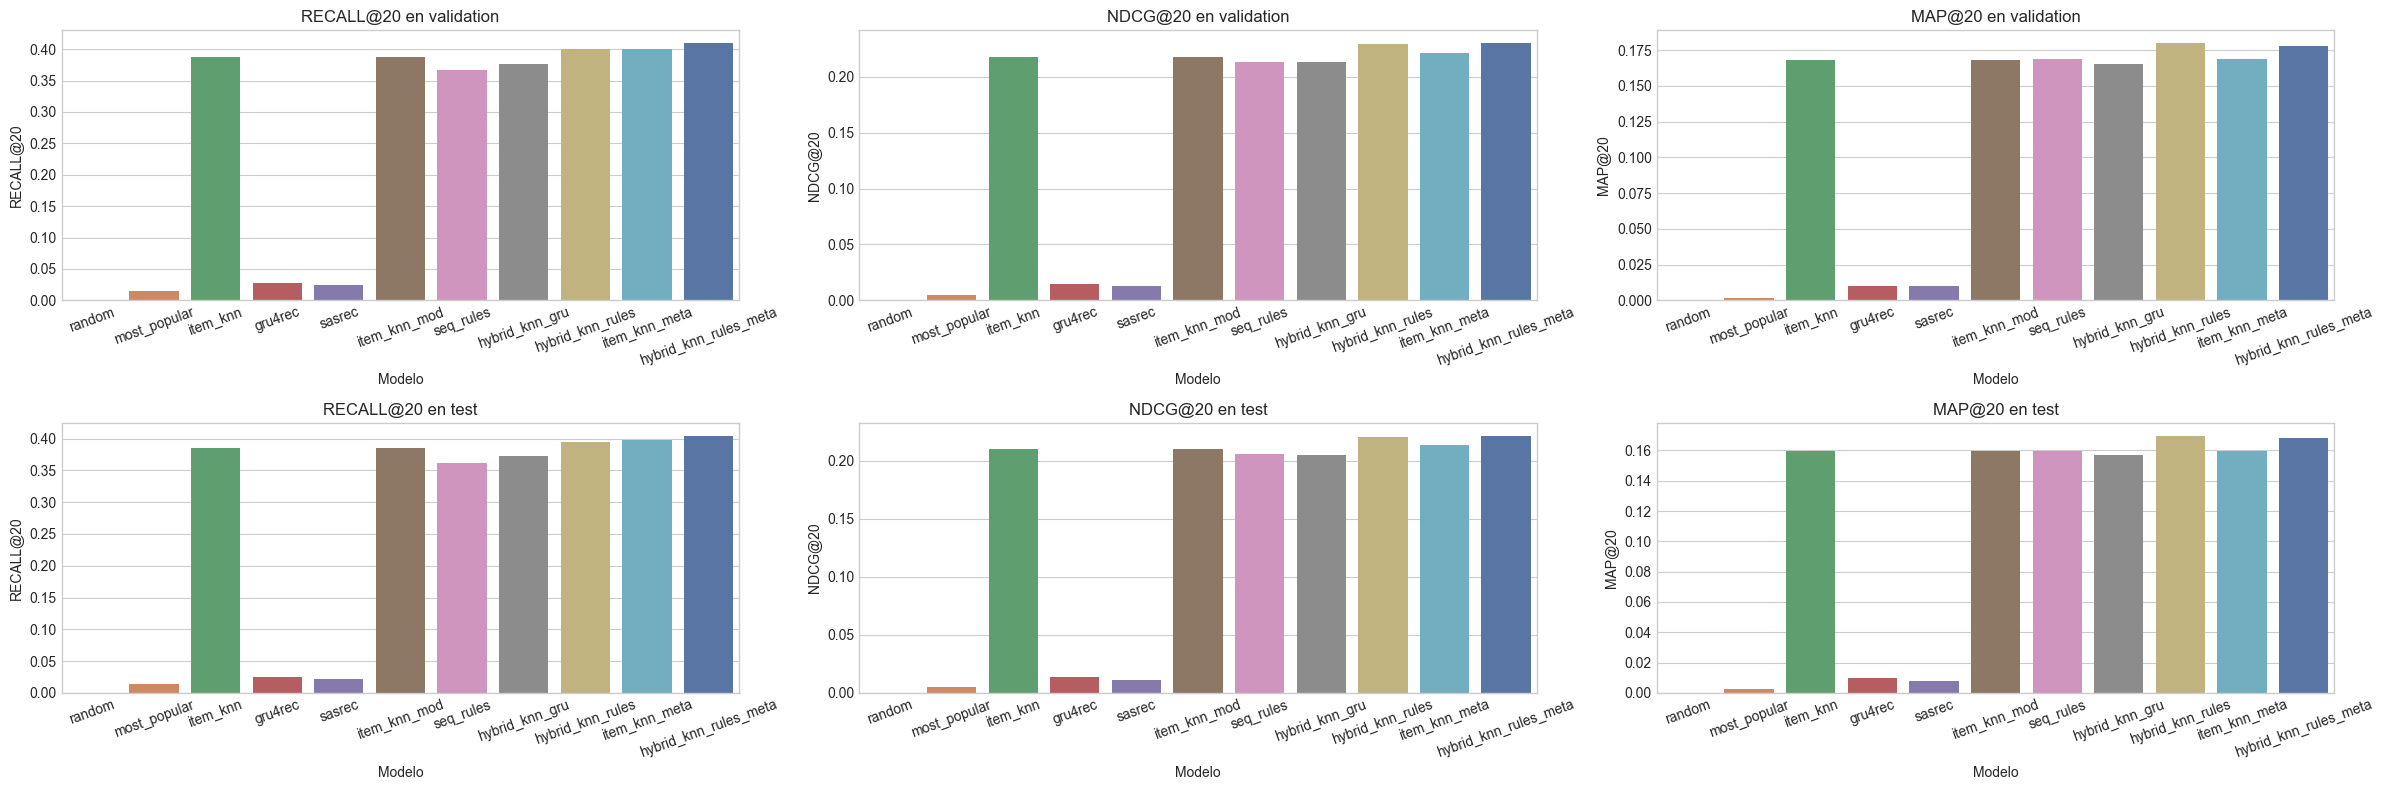

In [29]:
all_metadata_results = pd.concat([
    all_experiment_results,
    metadata_results_val.assign(split="validation"),
    metadata_results_test.assign(split="test"),
], ignore_index=True)

display(all_metadata_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(all_metadata_results, figsize=(24, 8))


### 7. Popularidad reciente e híbrido ajustado

Se agrega un modelo de popularidad reciente y se ajustan en validacion los pesos del hibrido `item_knn + seq_rules + recent_pop`. Luego se aplica el mismo reranking por metadata categorial sobre ese mejor híbrido.


In [30]:
train_session_ids_rr = set(train_sessions["session_id"])
train_events_rr = (
    events_with_sessions[events_with_sessions["session_id"].isin(train_session_ids_rr)]
    .copy()
    .rename(columns={"itemid": "product_id"})
)

recent_pop_recommender = ConstruirRecomendadorPopularidadReciente(
    train_events_rr[["event_time", "event_type", "product_id"]],
    recent_days=7,
    event_weights={"view": 1.0, "cart": 3.0, "purchase": 5.0},
    half_life_days=3.0,
)


def generar_grid_pesos_hibrido(step=0.25):
    pesos = np.arange(0.0, 1.0 + 1e-9, step)
    combinaciones = []

    for peso_knn in pesos:
        for peso_rules in pesos:
            peso_recent = 1.0 - peso_knn - peso_rules
            if peso_recent < -1e-9:
                continue
            if peso_recent < 1e-9:
                peso_recent = 0.0
            if peso_knn + peso_rules + peso_recent == 0:
                continue

            combinaciones.append({
                "peso_knn": round(float(peso_knn), 4),
                "peso_rules": round(float(peso_rules), 4),
                "peso_recent": round(float(peso_recent), 4),
            })

    return pd.DataFrame(combinaciones).drop_duplicates().reset_index(drop=True)


weight_grid_rr = generar_grid_pesos_hibrido(step=0.25)
weight_search_rows_rr = []
best_hybrid_tuned_recommender = None

for config in weight_grid_rr.itertuples(index=False):
    tuned_recommender = ConstruirRecomendadorHibrido(
        [
            ("item_knn", item_knn_recommender, config.peso_knn),
            ("seq_rules", seq_rules_recommender, config.peso_rules),
            ("recent_pop", recent_pop_recommender, config.peso_recent),
        ],
        popular_items=item_knn_recommender.popular_items,
    )
    scores_val = evaluate_recommender(tuned_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_tuned")
    metric_row = scores_val[scores_val["k"] == 20].iloc[0]

    weight_search_rows_rr.append({
        "peso_knn": config.peso_knn,
        "peso_rules": config.peso_rules,
        "peso_recent": config.peso_recent,
        "recall@20": metric_row["recall"],
        "ndcg@20": metric_row["ndcg"],
        "map@20": metric_row["map"],
        "recommender": tuned_recommender,
    })

weight_search_results_rr = pd.DataFrame(weight_search_rows_rr).sort_values(
    ["recall@20", "ndcg@20", "map@20"],
    ascending=False,
).reset_index(drop=True)

best_row_rr = weight_search_results_rr.iloc[0]
best_hybrid_tuned_recommender = best_row_rr["recommender"]
best_hybrid_tuned_weights_rr = {
    "item_knn": float(best_row_rr["peso_knn"]),
    "seq_rules": float(best_row_rr["peso_rules"]),
    "recent_pop": float(best_row_rr["peso_recent"]),
}

best_hybrid_tuned_meta_rr_recommender = construir_recomendador_rerank_categoria(
    best_hybrid_tuned_recommender,
    item_metadata_rr,
    popular_items=best_hybrid_tuned_recommender.popular_items,
    candidate_k=100,
)

display(weight_search_results_rr.drop(columns=["recommender"]).head(10))
display(pd.DataFrame([best_hybrid_tuned_weights_rr]))


,peso_knn,peso_rules,peso_recent,recall@20,ndcg@20,map@20
0,0.50,0.50,0.00,0.399483,0.230254,0.180756
1,0.25,0.75,0.00,0.396781,0.227209,0.177680
2,0.75,0.25,0.00,0.396781,0.225879,0.175822
3,1.00,0.00,0.00,0.388438,0.218262,0.168500
4,0.00,1.00,0.00,0.386676,0.221792,0.173538
5,0.50,0.25,0.25,0.365292,0.218051,0.174555
6,0.75,0.00,0.25,0.357890,0.208736,0.164795
7,0.25,0.50,0.25,0.355305,0.214127,0.172389
8,0.00,0.75,0.25,0.326989,0.201964,0.164682
9,0.50,0.00,0.50,0.260251,0.160687,0.132461


,item_knn,seq_rules,recent_pop
0,0.5,0.5,0.0


Validation


,modelo,k,recall,ndcg,map
3,hybrid_tuned,5,0.262954,0.190421,0.166459
6,hybrid_tuned_meta,5,0.262249,0.188384,0.163962
0,recent_pop,5,0.006110,0.003135,0.002172
7,hybrid_tuned_meta,10,0.342498,0.214276,0.174613
4,hybrid_tuned,10,0.337446,0.214532,0.176422
1,recent_pop,10,0.009635,0.004242,0.002608
8,hybrid_tuned_meta,20,0.411350,0.231720,0.179418
5,hybrid_tuned,20,0.399483,0.230254,0.180756
2,recent_pop,20,0.013629,0.005293,0.002918


Test


,modelo,k,recall,ndcg,map
3,hybrid_tuned,5,0.253544,0.180029,0.155729
6,hybrid_tuned_meta,5,0.252599,0.178564,0.154106
0,recent_pop,5,0.005400,0.003536,0.002932
7,hybrid_tuned_meta,10,0.331038,0.203951,0.164598
4,hybrid_tuned,10,0.323883,0.202910,0.165251
1,recent_pop,10,0.009991,0.005017,0.003540
8,hybrid_tuned_meta,20,0.404887,0.222781,0.169847
5,hybrid_tuned,20,0.394357,0.220849,0.170238
2,recent_pop,20,0.015526,0.006460,0.003959


,modelo,k,recall,ndcg,map,split
78,hybrid_tuned,5,0.253544,0.180029,0.155729,test
63,hybrid_knn_rules_meta,5,0.252734,0.177618,0.152813,test
81,hybrid_tuned_meta,5,0.252599,0.178564,0.154106,test
51,hybrid_knn_rules,5,0.252329,0.179196,0.155011,test
60,item_knn_meta,5,0.243283,0.168631,0.144033,test
...,...,...,...,...,...,...
11,gru4rec,20,0.027964,0.014244,0.010371,validation
14,sasrec,20,0.024674,0.013073,0.009843,validation
5,most_popular,20,0.014099,0.004526,0.001937,validation
68,recent_pop,20,0.013629,0.005293,0.002918,validation


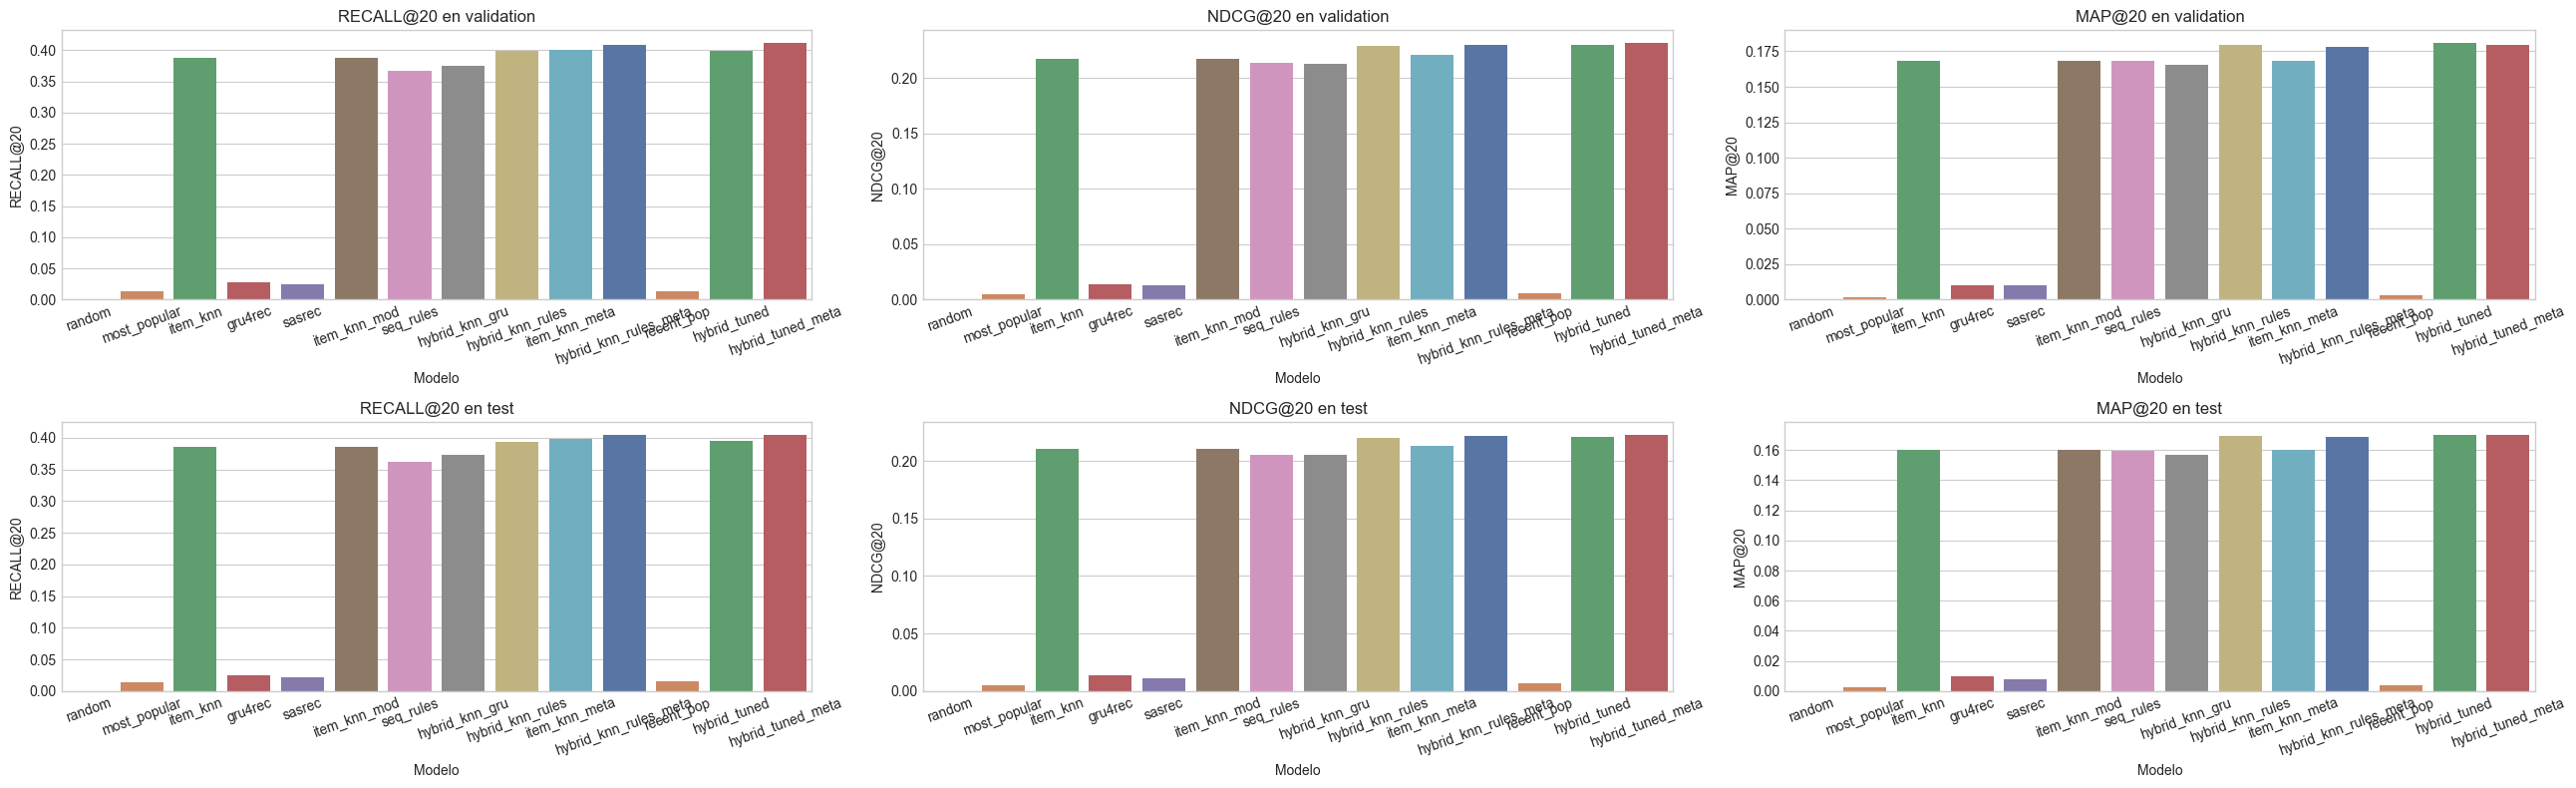

In [31]:
tuned_results_val = pd.concat([
    evaluate_recommender(recent_pop_recommender.Recomendar, val_eval, ks=TOP_KS, label="recent_pop"),
    evaluate_recommender(best_hybrid_tuned_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_tuned"),
    evaluate_recommender(best_hybrid_tuned_meta_rr_recommender.Recomendar, val_eval, ks=TOP_KS, label="hybrid_tuned_meta"),
], ignore_index=True)

tuned_results_test = pd.concat([
    evaluate_recommender(recent_pop_recommender.Recomendar, test_eval, ks=TOP_KS, label="recent_pop"),
    evaluate_recommender(best_hybrid_tuned_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_tuned"),
    evaluate_recommender(best_hybrid_tuned_meta_rr_recommender.Recomendar, test_eval, ks=TOP_KS, label="hybrid_tuned_meta"),
], ignore_index=True)

all_comparable_results = pd.concat([
    all_metadata_results,
    tuned_results_val.assign(split="validation"),
    tuned_results_test.assign(split="test"),
], ignore_index=True)

print("Validation")
display(tuned_results_val.sort_values(["k", "recall"], ascending=[True, False]))
print("Test")
display(tuned_results_test.sort_values(["k", "recall"], ascending=[True, False]))

display(all_comparable_results.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(all_comparable_results, figsize=(26, 8))


### 8. Análisis segmentado de resultados

Para entender mejor en que condiciones mejora cada variante, se segmenta el conjunto de test por longitud de sesión, popularidad del item objetivo y disponibilidad de metadata del target.


In [32]:
def evaluate_recommender_detailed(recommender_fn, eval_cases, ks=(5, 10, 20), label="model"):
    rows = []
    for fila in eval_cases.itertuples(index=False):
        max_k = max(ks)
        recs = recommender_fn(fila.prefix_items, k=max_k)
        relevant = [fila.target_item]

        target_rank = next((idx + 1 for idx, item in enumerate(recs) if item == fila.target_item), np.nan)

        for k in ks:
            rows.append({
                "modelo": label,
                "k": k,
                "case_idx": getattr(fila, "case_idx", np.nan),
                "session_len_bucket": fila.session_len_bucket,
                "target_pop_bucket": fila.target_pop_bucket,
                "target_metadata_bucket": fila.target_metadata_bucket,
                "recall": recall_at_k(recs, relevant, k),
                "ndcg": ndcg_at_k(recs, relevant, k),
                "map": average_precision_at_k(recs, relevant, k),
                "hit": float(fila.target_item in recs[:k]),
                "target_rank": target_rank,
            })

    return pd.DataFrame(rows)


def build_segmented_eval_cases(eval_cases, train_sessions, item_metadata_df):
    casos = eval_cases.copy().reset_index(drop=True)
    casos["case_idx"] = casos.index
    casos["session_len_total"] = casos["prefix_len"] + 1

    casos["session_len_bucket"] = pd.cut(
        casos["session_len_total"],
        bins=[1, 3, 6, np.inf],
        labels=["corta_2_3", "media_4_6", "larga_7_plus"],
        include_lowest=True,
    ).astype(str)

    item_support = Counter(item for seq in train_sessions["items"] for item in seq)
    casos["target_support_train"] = casos["target_item"].map(item_support).fillna(0).astype(int)

    nonzero_support = casos.loc[casos["target_support_train"] > 0, "target_support_train"]
    if len(nonzero_support) > 0:
        q_mid = float(nonzero_support.quantile(0.5))
        q_head = float(nonzero_support.quantile(0.8))
    else:
        q_mid, q_head = 1.0, 1.0

    casos["target_pop_bucket"] = np.where(
        casos["target_support_train"] >= q_head,
        "head",
        np.where(casos["target_support_train"] >= q_mid, "mid", "tail"),
    )

    metadata_lookup = item_metadata_df.set_index("product_id").to_dict(orient="index") if not item_metadata_df.empty else {}
    casos["target_has_metadata"] = casos["target_item"].apply(lambda item: item in metadata_lookup)
    casos["target_metadata_bucket"] = np.where(casos["target_has_metadata"], "con_metadata", "sin_metadata")
    return casos


def resumir_metricas_por_segmento(detailed_results, segmented_cases, segment_col, ks=(5, 10, 20)):
    rows = []
    for k in ks:
        subset = detailed_results[detailed_results["k"] == k].copy()
        grouped = subset.groupby(["modelo", segment_col], dropna=False).agg(
            recall=("recall", "mean"),
            ndcg=("ndcg", "mean"),
            map=("map", "mean"),
            hit_rate=("hit", "mean"),
            mean_rank=("target_rank", "mean"),
        ).reset_index()

        case_counts = segmented_cases.groupby(segment_col, dropna=False).size().rename("casos").reset_index()
        grouped = grouped.merge(case_counts, on=segment_col, how="left")
        grouped["k"] = k
        rows.append(grouped)

    return pd.concat(rows, ignore_index=True)


def construir_delta_segmento(segment_summary, base_model, improved_model, segment_col, k=20):
    subset = segment_summary[segment_summary["k"] == k].copy()
    base = subset[subset["modelo"] == base_model].set_index(segment_col)
    improved = subset[subset["modelo"] == improved_model].set_index(segment_col)
    common = base.index.intersection(improved.index)
    delta = pd.DataFrame({
        segment_col: common,
        "comparacion": f"{improved_model} - {base_model}",
        "recall": improved.loc[common, "recall"].values - base.loc[common, "recall"].values,
        "ndcg": improved.loc[common, "ndcg"].values - base.loc[common, "ndcg"].values,
        "map": improved.loc[common, "map"].values - base.loc[common, "map"].values,
    })
    return delta.reset_index(drop=True)


In [33]:
segmented_test_cases = build_segmented_eval_cases(test_eval, train_sessions, item_metadata_rr)

display(segmented_test_cases[[
    "case_idx",
    "session_len_total",
    "session_len_bucket",
    "target_support_train",
    "target_pop_bucket",
    "target_metadata_bucket",
]].head())

for column in ["session_len_bucket", "target_pop_bucket", "target_metadata_bucket"]:
    print(f"Distribucion de casos por {column}:")
    display(segmented_test_cases[column].value_counts(dropna=False).rename_axis(column).reset_index(name="casos"))


,case_idx,session_len_total,session_len_bucket,target_support_train,target_pop_bucket,target_metadata_bucket
0,0,4,media_4_6,35,mid,con_metadata
1,1,2,corta_2_3,26,tail,con_metadata
2,2,2,corta_2_3,104,head,sin_metadata
3,3,5,media_4_6,39,mid,con_metadata
4,4,4,media_4_6,70,mid,con_metadata


Distribucion de casos por session_len_bucket:


,session_len_bucket,casos
0,corta_2_3,5549
1,media_4_6,1294
2,larga_7_plus,564


Distribucion de casos por target_pop_bucket:


,target_pop_bucket,casos
0,tail,3673
1,mid,2250
2,head,1484


Distribucion de casos por target_metadata_bucket:


,target_metadata_bucket,casos
0,con_metadata,7169
1,sin_metadata,238


In [34]:
segment_models = [
    ("item_knn", item_knn_recommender.Recomendar),
    ("item_knn_meta", item_knn_meta_rr_recommender.Recomendar),
    ("gru4rec", gru4rec_recommender.Recomendar),
    ("sasrec", sasrec_recommender.Recomendar),
    ("hybrid_tuned", best_hybrid_tuned_recommender.Recomendar),
    ("hybrid_tuned_meta", best_hybrid_tuned_meta_rr_recommender.Recomendar),
]

detailed_segment_results = pd.concat([
    evaluate_recommender_detailed(recommender_fn, segmented_test_cases, ks=TOP_KS, label=label)
    for label, recommender_fn in segment_models
], ignore_index=True)

display(detailed_segment_results.head())


,modelo,k,case_idx,session_len_bucket,target_pop_bucket,target_metadata_bucket,recall,ndcg,map,hit,target_rank
0,item_knn,5,0,media_4_6,mid,con_metadata,0.0,0.0,0.0,0.0,NaN
1,item_knn,10,0,media_4_6,mid,con_metadata,0.0,0.0,0.0,0.0,NaN
2,item_knn,20,0,media_4_6,mid,con_metadata,0.0,0.0,0.0,0.0,NaN
3,item_knn,5,1,corta_2_3,tail,con_metadata,0.0,0.0,0.0,0.0,20.0
4,item_knn,10,1,corta_2_3,tail,con_metadata,0.0,0.0,0.0,0.0,20.0


In [35]:
session_length_summary = resumir_metricas_por_segmento(detailed_segment_results, segmented_test_cases, "session_len_bucket", ks=TOP_KS)
target_pop_summary = resumir_metricas_por_segmento(detailed_segment_results, segmented_test_cases, "target_pop_bucket", ks=TOP_KS)
metadata_summary_segment = resumir_metricas_por_segmento(detailed_segment_results, segmented_test_cases, "target_metadata_bucket", ks=TOP_KS)

display(session_length_summary.sort_values(["k", "session_len_bucket", "recall"], ascending=[True, True, False]))
display(target_pop_summary.sort_values(["k", "target_pop_bucket", "recall"], ascending=[True, True, False]))
display(metadata_summary_segment.sort_values(["k", "target_metadata_bucket", "recall"], ascending=[True, True, False]))


,modelo,session_len_bucket,recall,ndcg,map,hit_rate,mean_rank,casos,k
3,hybrid_tuned,corta_2_3,0.292846,0.208579,0.180732,0.292846,5.194922,5549,5
6,hybrid_tuned_meta,corta_2_3,0.291944,0.206770,0.178639,0.291944,5.348485,5549,5
12,item_knn_meta,corta_2_3,0.283474,0.196400,0.167697,0.283474,5.494505,5549,5
9,item_knn,corta_2_3,0.277167,0.195253,0.168229,0.277167,5.356544,5549,5
0,gru4rec,corta_2_3,0.016039,0.011928,0.010584,0.016039,6.689024,5549,5
15,sasrec,corta_2_3,0.013696,0.010062,0.008857,0.013696,6.912752,5549,5
7,hybrid_tuned_meta,larga_7_plus,0.090426,0.064843,0.056383,0.090426,6.640000,564,5
4,hybrid_tuned,larga_7_plus,0.088652,0.062670,0.054108,0.088652,6.729167,564,5
10,item_knn,larga_7_plus,0.078014,0.058550,0.052187,0.078014,7.086957,564,5
13,item_knn_meta,larga_7_plus,0.078014,0.058561,0.052128,0.078014,7.376238,564,5


,modelo,target_pop_bucket,recall,ndcg,map,hit_rate,mean_rank,casos,k
3,hybrid_tuned,head,0.353100,0.257852,0.226280,0.353100,5.028834,1484,5
6,hybrid_tuned_meta,head,0.337601,0.245262,0.214623,0.337601,5.253927,1484,5
12,item_knn_meta,head,0.298518,0.207523,0.177516,0.298518,5.934903,1484,5
9,item_knn,head,0.297170,0.213361,0.185624,0.297170,5.642553,1484,5
0,gru4rec,head,0.068733,0.050100,0.044003,0.068733,6.747312,1484,5
15,sasrec,head,0.053235,0.039402,0.034805,0.053235,6.903846,1484,5
4,hybrid_tuned,mid,0.282667,0.201135,0.174274,0.282667,5.119247,2250,5
7,hybrid_tuned_meta,mid,0.279556,0.199667,0.173341,0.279556,5.233607,2250,5
13,item_knn_meta,mid,0.257778,0.178724,0.152711,0.257778,5.760252,2250,5
10,item_knn,mid,0.249778,0.174140,0.149252,0.249778,5.606791,2250,5


,modelo,target_metadata_bucket,recall,ndcg,map,hit_rate,mean_rank,casos,k
4,hybrid_tuned_meta,con_metadata,0.257219,0.181931,0.157037,0.257219,5.533288,7169,5
2,hybrid_tuned,con_metadata,0.256382,0.181990,0.157391,0.256382,5.444755,7169,5
8,item_knn_meta,con_metadata,0.248431,0.171818,0.146569,0.248431,5.745499,7169,5
6,item_knn,con_metadata,0.240619,0.168908,0.145250,0.240619,5.658659,7169,5
0,gru4rec,con_metadata,0.014228,0.010371,0.009109,0.014228,6.836842,7169,5
10,sasrec,con_metadata,0.011438,0.008330,0.007302,0.011438,6.969136,7169,5
7,item_knn,sin_metadata,0.176471,0.140672,0.128711,0.176471,5.177419,238,5
3,hybrid_tuned,sin_metadata,0.168067,0.120948,0.105672,0.168067,5.163934,238,5
5,hybrid_tuned_meta,sin_metadata,0.113445,0.077146,0.065826,0.113445,8.109091,238,5
9,item_knn_meta,sin_metadata,0.088235,0.072621,0.067647,0.088235,9.068966,238,5


In [36]:
delta_item_knn_meta_by_length = construir_delta_segmento(session_length_summary, "item_knn", "item_knn_meta", "session_len_bucket", k=20)
delta_hybrid_meta_by_length = construir_delta_segmento(session_length_summary, "hybrid_tuned", "hybrid_tuned_meta", "session_len_bucket", k=20)

delta_item_knn_meta_by_pop = construir_delta_segmento(target_pop_summary, "item_knn", "item_knn_meta", "target_pop_bucket", k=20)
delta_hybrid_meta_by_pop = construir_delta_segmento(target_pop_summary, "hybrid_tuned", "hybrid_tuned_meta", "target_pop_bucket", k=20)

delta_item_knn_meta_by_metadata = construir_delta_segmento(metadata_summary_segment, "item_knn", "item_knn_meta", "target_metadata_bucket", k=20)
delta_hybrid_meta_by_metadata = construir_delta_segmento(metadata_summary_segment, "hybrid_tuned", "hybrid_tuned_meta", "target_metadata_bucket", k=20)

print("Aporte del reranking con metadata sobre Item-KNN a Recall/NDCG/MAP@20")
display(delta_item_knn_meta_by_length)
display(delta_item_knn_meta_by_pop)
display(delta_item_knn_meta_by_metadata)

print("Aporte del reranking con metadata sobre el hibrido a Recall/NDCG/MAP@20")
display(delta_hybrid_meta_by_length)
display(delta_hybrid_meta_by_pop)
display(delta_hybrid_meta_by_metadata)


Aporte del reranking con metadata sobre Item-KNN a Recall/NDCG/MAP@20


,session_len_bucket,comparacion,recall,ndcg,map
0,corta_2_3,item_knn_meta - item_knn,0.013156,0.002907,-0.000028
1,larga_7_plus,item_knn_meta - item_knn,0.015957,0.004471,0.001399
2,media_4_6,item_knn_meta - item_knn,0.010046,0.001188,-0.001002


,target_pop_bucket,comparacion,recall,ndcg,map
0,head,item_knn_meta - item_knn,0.011456,-0.003403,-0.007524
1,mid,item_knn_meta - item_knn,0.016889,0.006846,0.004098
2,tail,item_knn_meta - item_knn,0.010890,0.002678,0.000348


,target_metadata_bucket,comparacion,recall,ndcg,map
0,con_metadata,item_knn_meta - item_knn,0.013809,0.004448,0.001742
1,sin_metadata,item_knn_meta - item_knn,-0.016807,-0.049140,-0.055272


Aporte del reranking con metadata sobre el hibrido a Recall/NDCG/MAP@20


,session_len_bucket,comparacion,recall,ndcg,map
0,corta_2_3,hybrid_tuned_meta - hybrid_tuned,0.011894,0.001968,-0.000731
1,larga_7_plus,hybrid_tuned_meta - hybrid_tuned,0.007092,0.003894,0.002976
2,media_4_6,hybrid_tuned_meta - hybrid_tuned,0.006182,0.000924,-0.000400


,target_pop_bucket,comparacion,recall,ndcg,map
0,head,hybrid_tuned_meta - hybrid_tuned,0.000674,-0.007555,-0.009666
1,mid,hybrid_tuned_meta - hybrid_tuned,0.008889,0.002355,0.000626
2,tail,hybrid_tuned_meta - hybrid_tuned,0.015519,0.005507,0.002734


,target_metadata_bucket,comparacion,recall,ndcg,map
0,con_metadata,hybrid_tuned_meta - hybrid_tuned,0.011717,0.003268,0.000911
1,sin_metadata,hybrid_tuned_meta - hybrid_tuned,-0.025210,-0.038299,-0.039596


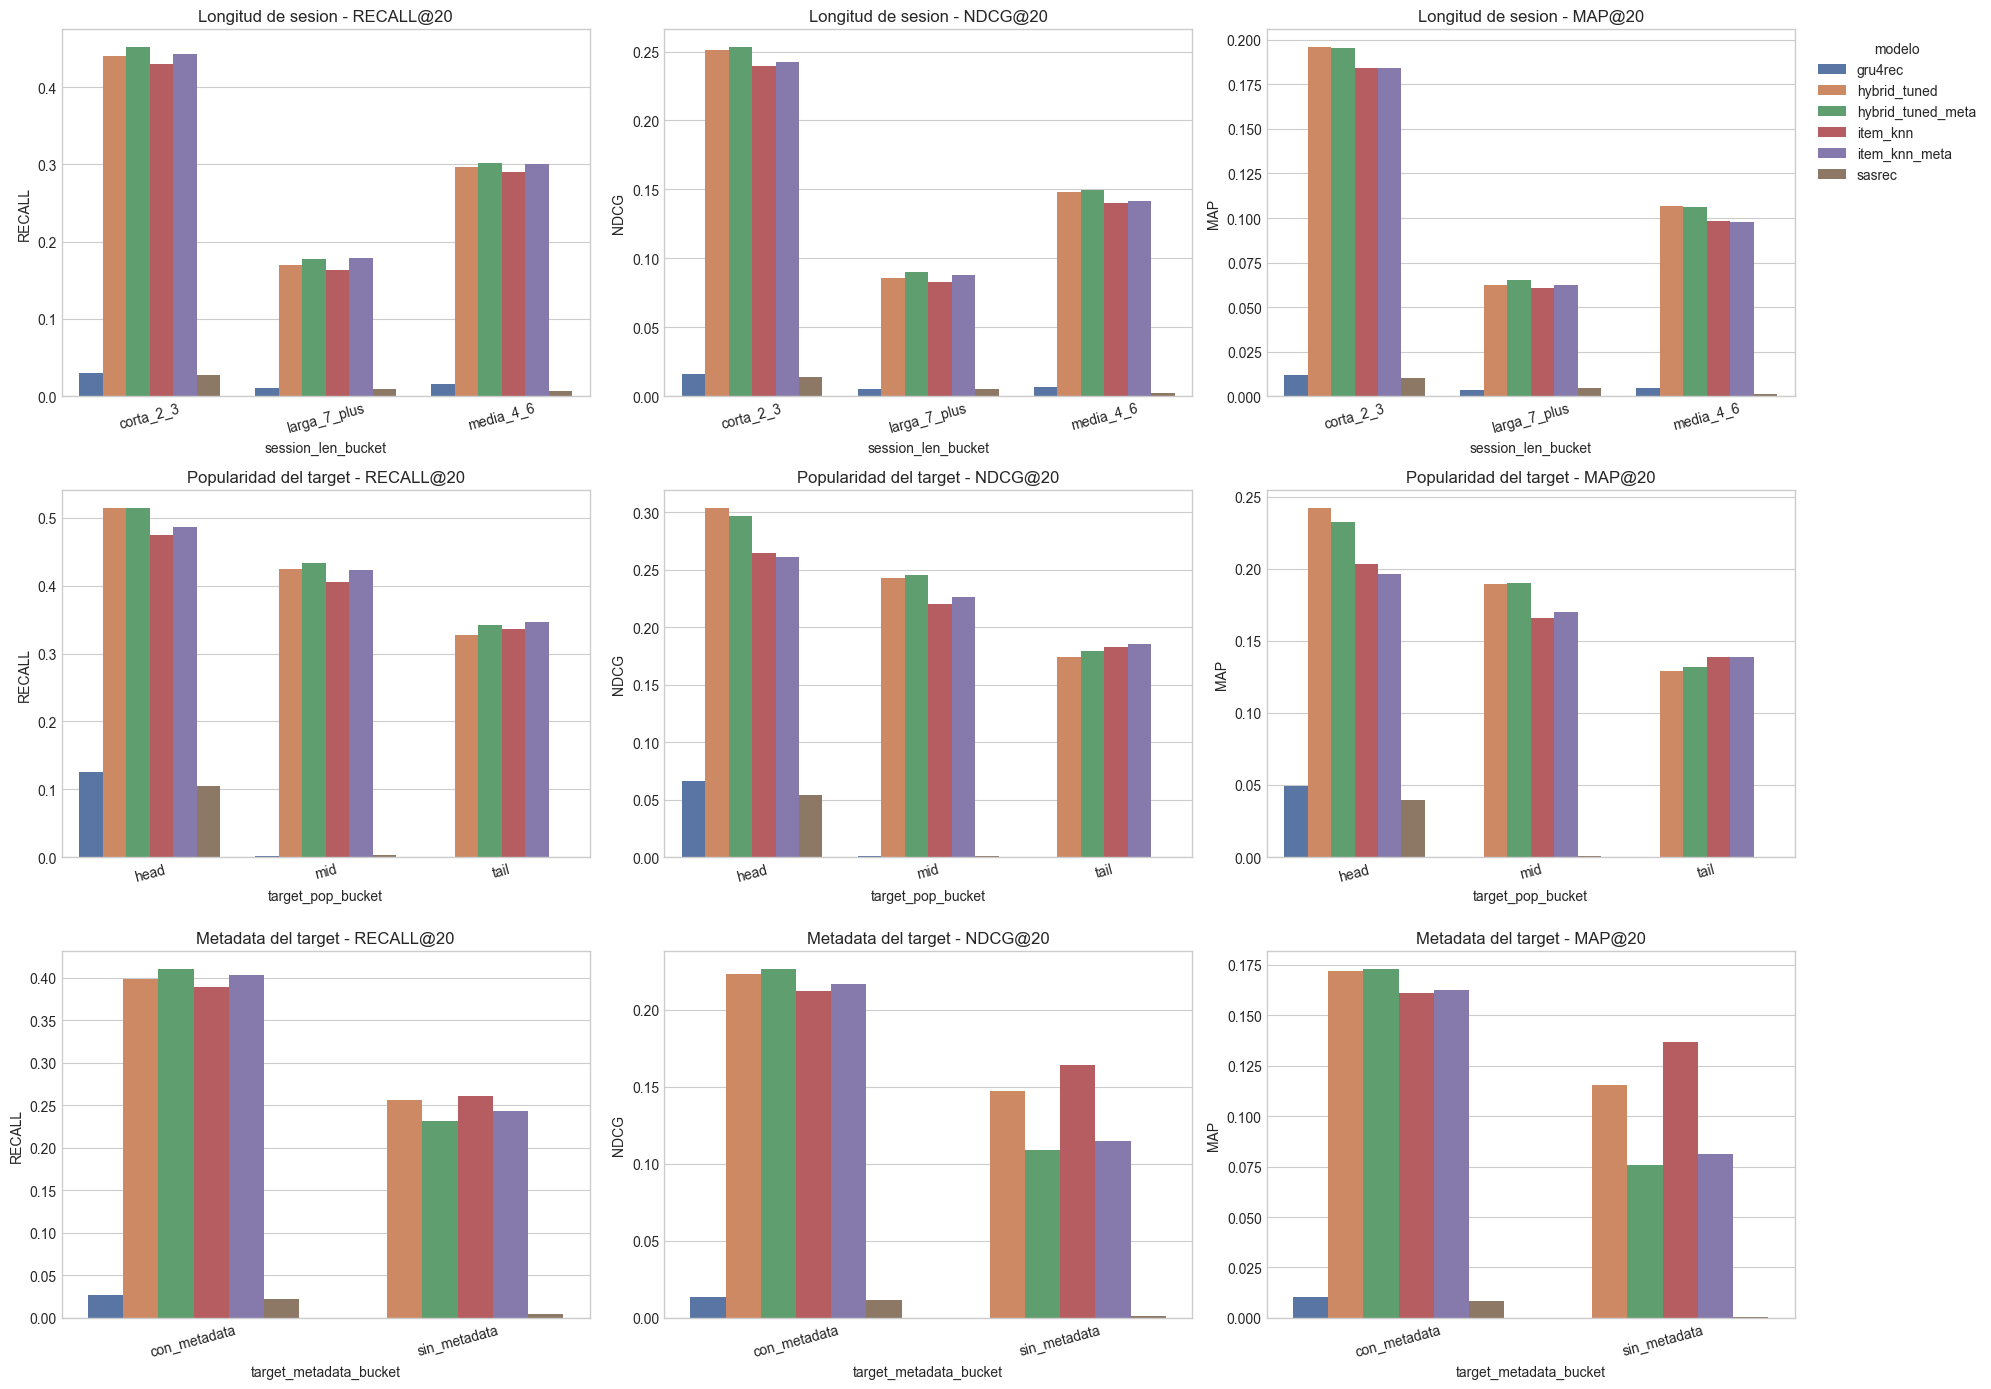

In [37]:
plot_models = ["item_knn", "item_knn_meta", "gru4rec", "sasrec", "hybrid_tuned", "hybrid_tuned_meta"]
plot_specs = [
    (session_length_summary, "session_len_bucket", "Longitud de sesion"),
    (target_pop_summary, "target_pop_bucket", "Popularidad del target"),
    (metadata_summary_segment, "target_metadata_bucket", "Metadata del target"),
]

fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for row_idx, (summary_df, segment_col, title_prefix) in enumerate(plot_specs):
    subset = summary_df[(summary_df["k"] == 20) & (summary_df["modelo"].isin(plot_models))].copy()
    for col_idx, metric in enumerate(["recall", "ndcg", "map"]):
        ax = axes[row_idx, col_idx]
        sns.barplot(data=subset, x=segment_col, y=metric, hue="modelo", ax=ax)
        ax.set_title(f"{title_prefix} - {metric.upper()}@20")
        ax.set_xlabel(segment_col)
        ax.set_ylabel(metric.upper())
        ax.tick_params(axis="x", rotation=15)
        if row_idx == 0 and col_idx == 2:
            ax.legend(title="modelo", bbox_to_anchor=(1.02, 1), loc="upper left")
        else:
            ax.get_legend().remove()

plt.tight_layout()
plt.show()


### 9. TALE (extensión exploratoria)

Se integra una version de `TALE`. Se mantiene como extensión exploratoria y se limita el catálogo al top-N de `train` para que el experimento siga siendo viable.


In [38]:
from ECommerce_TALE import (
    ConstruirSesionesConTiempo,
    FiltrarItemsTrainYProyectarSplitsTALE,
    LimitarCatalogoTALEPorPopularidad,
    ConstruirResumenSplitsTALE,
    EntrenarTALE,
    HiperparametrosTALE,
)

TALE_MAX_CATALOG_ITEMS = 2_000


In [39]:
tale_events = events_with_sessions.rename(columns={
    "session_id": "user_session",
    "itemid": "product_id",
    "visitorid": "user_id",
}).copy()

tale_session_sequences = ConstruirSesionesConTiempo(tale_events[["user_session", "product_id", "event_time", "user_id"]])

if DROP_LAST_DAY_FROM_SPLIT:
    max_day = tale_session_sequences["end_time"].dt.normalize().max()
    tale_session_sequences = tale_session_sequences[tale_session_sequences["end_time"].dt.normalize() < max_day].copy().reset_index(drop=True)

def separar_sesiones_tale_manual(session_df, validation_days=7, test_days=7):
    sesiones_ordenadas = session_df.sort_values("end_time").reset_index(drop=True)
    fechas_fin = sesiones_ordenadas["end_time"].dt.normalize()
    fechas_unicas = fechas_fin.drop_duplicates().sort_values().reset_index(drop=True)
    dias_necesarios = validation_days + test_days + 1
    if len(fechas_unicas) < dias_necesarios:
        raise ValueError("No hay suficientes fechas distintas para crear split TALE.")

    inicio_test = fechas_unicas.iloc[-test_days]
    inicio_validacion = fechas_unicas.iloc[-(test_days + validation_days)]

    train_df = sesiones_ordenadas[fechas_fin < inicio_validacion].copy()
    val_df = sesiones_ordenadas[(fechas_fin >= inicio_validacion) & (fechas_fin < inicio_test)].copy()
    test_df = sesiones_ordenadas[fechas_fin >= inicio_test].copy()
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

tale_train_raw, tale_val_raw, tale_test_raw = separar_sesiones_tale_manual(
    tale_session_sequences,
    validation_days=VALIDATION_DAYS,
    test_days=TEST_DAYS,
)

tale_train_sessions, tale_val_sessions, tale_test_sessions = FiltrarItemsTrainYProyectarSplitsTALE(
    tale_train_raw,
    tale_val_raw,
    tale_test_raw,
    min_session_len=MIN_SESSION_LEN,
    min_item_support=MIN_ITEM_SUPPORT,
)

tale_train_sessions, tale_val_sessions, tale_test_sessions, tale_catalog_limited = LimitarCatalogoTALEPorPopularidad(
    tale_train_sessions,
    tale_val_sessions,
    tale_test_sessions,
    max_catalog_items=TALE_MAX_CATALOG_ITEMS,
    min_session_len=MIN_SESSION_LEN,
)

display(ConstruirResumenSplitsTALE(tale_train_sessions, tale_val_sessions, tale_test_sessions))
print(f"TALE se entrena sobre el top-{TALE_MAX_CATALOG_ITEMS:,} de items de train para mantener viable la forma cerrada.")


,split,sesiones,interacciones,items_unicos,inicio,fin
0,train,54764,177905,2000,2015-05-03 03:05:52.333000+00:00,2015-09-03 23:59:35.612000+00:00
1,validation,2242,6638,1212,2015-09-04 00:03:19.123000+00:00,2015-09-10 23:58:10.877000+00:00
2,test,1912,5781,1126,2015-09-11 00:07:17.320000+00:00,2015-09-17 23:52:07.378000+00:00


TALE se entrena sobre el top-2,000 de items de train para mantener viable la forma cerrada.


In [40]:
def build_eval_cases_tale(session_df, max_session_len=20):
    eval_cases = session_df.copy()
    eval_cases["prefix_items"] = eval_cases["items"].apply(lambda seq: seq[:-1][-max_session_len:])
    eval_cases["target_item"] = eval_cases["items"].apply(lambda seq: seq[-1])
    eval_cases["prefix_len"] = eval_cases["prefix_items"].apply(len)
    eval_cases = eval_cases[eval_cases["prefix_len"] >= 1].copy().reset_index(drop=True)
    return eval_cases

tale_val_eval = build_eval_cases_tale(tale_val_sessions, max_session_len=MAX_SESSION_LEN)
tale_test_eval = build_eval_cases_tale(tale_test_sessions, max_session_len=MAX_SESSION_LEN)

print(f"Casos TALE - validation: {len(tale_val_eval):,}")
print(f"Casos TALE - test: {len(tale_test_eval):,}")


Casos TALE - validation: 2,242
Casos TALE - test: 1,912


In [41]:
tale_configs = HiperparametrosTALE()
best_tale_config_name = None
best_tale_config = None
best_tale_recall = -np.inf
tale_results_val_all = []

for config_name, config in tale_configs.items():
    config = {**config, "max_catalog_items": TALE_MAX_CATALOG_ITEMS}
    tale_candidate = EntrenarTALE(tale_train_sessions, verbose=False, **config)
    val_result = evaluate_recommender(tale_candidate.Recomendar, tale_val_eval, ks=TOP_KS, label="tale")
    val_result["config"] = config_name
    tale_results_val_all.append(val_result)

    recall20 = float(val_result.loc[val_result["k"] == 20, "recall"].iloc[0])
    if recall20 > best_tale_recall:
        best_tale_recall = recall20
        best_tale_config_name = config_name
        best_tale_config = config

tale_results_val_grid = pd.concat(tale_results_val_all, ignore_index=True)
display(tale_results_val_grid.sort_values(["k", "recall"], ascending=[True, False]))
print(f"Mejor configuracion TALE en validation Recall@20: {best_tale_config_name}")


,modelo,k,recall,ndcg,map,config
0,tale,5,0.328724,0.236665,0.206148,balanced
3,tale,5,0.327832,0.238815,0.209181,short_term
6,tale,5,0.327386,0.236660,0.206624,long_term
1,tale,10,0.404550,0.261193,0.216274,balanced
7,tale,10,0.401427,0.260715,0.216616,long_term
4,tale,10,0.400535,0.262271,0.218832,short_term
8,tale,20,0.477698,0.280120,0.222007,long_term
2,tale,20,0.472346,0.278471,0.221088,balanced
5,tale,20,0.472346,0.280666,0.224005,short_term


Mejor configuracion TALE en validation Recall@20: long_term


In [42]:
tale_recommender = EntrenarTALE(tale_train_sessions, verbose=True, **best_tale_config)
tale_results_val = evaluate_recommender(tale_recommender.Recomendar, tale_val_eval, ks=TOP_KS, label="tale")
tale_results_test = evaluate_recommender(tale_recommender.Recomendar, tale_test_eval, ks=TOP_KS, label="tale")

print("Validation")
display(tale_results_val.sort_values(["k", "recall"], ascending=[True, False]))
print("Test")
display(tale_results_test.sort_values(["k", "recall"], ascending=[True, False]))


TALE: sesiones=54,764, ejemplos=123,141, items=2,000, lambda=300.000
Validation


,modelo,k,recall,ndcg,map
0,tale,5,0.327386,0.236660,0.206624
1,tale,10,0.401427,0.260715,0.216616
2,tale,20,0.477698,0.280120,0.222007


Test


,modelo,k,recall,ndcg,map
0,tale,5,0.320084,0.232136,0.203068
1,tale,10,0.392259,0.255388,0.212612
2,tale,20,0.468619,0.274752,0.217953


,modelo,k,recall,ndcg,map,split
87,tale,5,0.320084,0.232136,0.203068,test
78,hybrid_tuned,5,0.253544,0.180029,0.155729,test
63,hybrid_knn_rules_meta,5,0.252734,0.177618,0.152813,test
81,hybrid_tuned_meta,5,0.252599,0.178564,0.154106,test
51,hybrid_knn_rules,5,0.252329,0.179196,0.155011,test
...,...,...,...,...,...,...
11,gru4rec,20,0.027964,0.014244,0.010371,validation
14,sasrec,20,0.024674,0.013073,0.009843,validation
5,most_popular,20,0.014099,0.004526,0.001937,validation
68,recent_pop,20,0.013629,0.005293,0.002918,validation


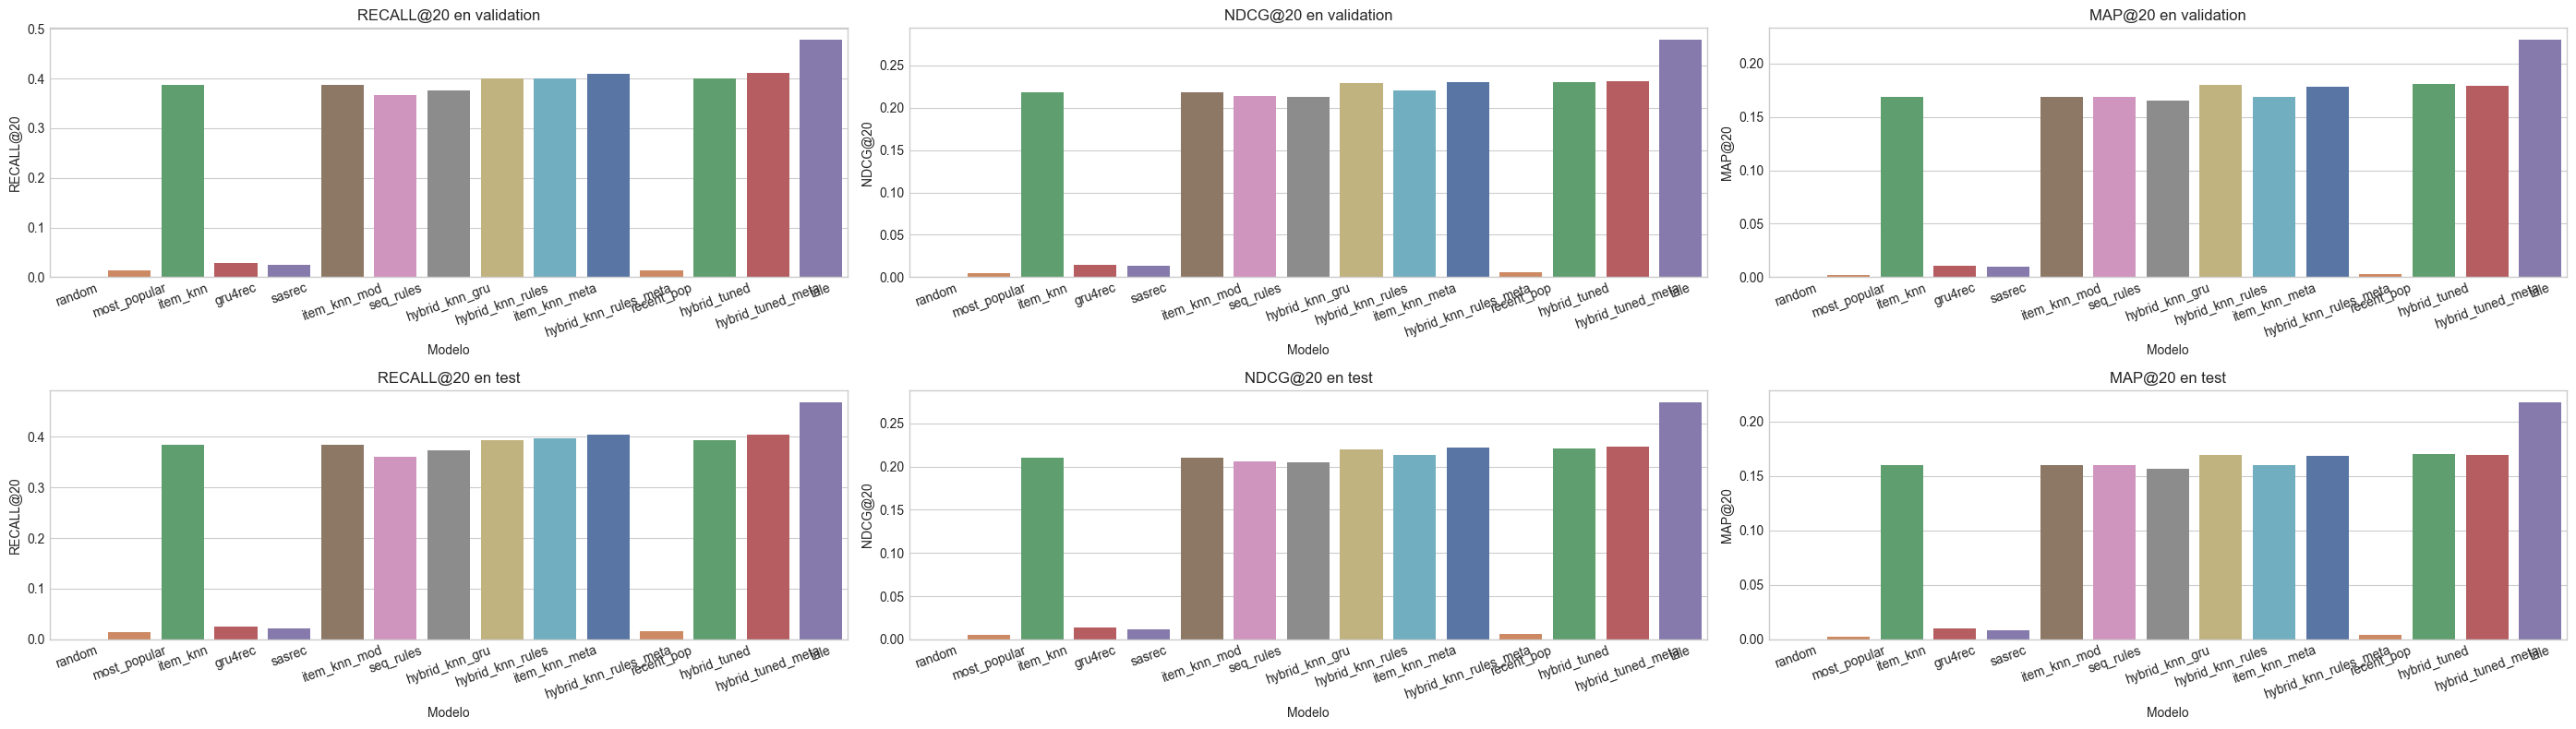

In [43]:
all_results_with_tale = pd.concat([
    all_comparable_results,
    tale_results_val.assign(split="validation"),
    tale_results_test.assign(split="test"),
], ignore_index=True)

display(all_results_with_tale.sort_values(["split", "k", "recall"], ascending=[True, True, False]))
plot_metric_comparison(all_results_with_tale, figsize=(28, 8))


### 10. Exportación de resultados


In [48]:
import importlib
import ECommerce_Exports
importlib.reload(ECommerce_Exports)

from ECommerce_Exports import ExportarDataFramesExcel

export_tables = {
    "events_summary": events_summary,
    "split_summary": split_summary,
    "final_results": all_results_with_tale,
    "best_weights": pd.DataFrame([best_hybrid_tuned_weights_rr]),
    "segment_session_len": session_length_summary,
    "segment_target_pop": target_pop_summary,
    "segment_metadata": metadata_summary_segment,
}

export_path = ExportarDataFramesExcel(
    export_tables, "retailrocket_results.xlsx",
)

print(f"Resultados exportados a: {export_path}")


Resultados exportados a: retailrocket_results.xlsx
